##### Last updated: 2026 August 17

# "Brief" tutorial on light curve modeling with lcurve, using our Python wrapper version.
#### This notebook was built to use the wrapper version of lcurve from 2026 August 13 or later. Be sure to load the correct Python kernel for this.

This Jupyter notebook covers the information necessary to use lcurve for light curve model fitting, specifically with our updated wrapper version of lcurve. This tutorial uses Jupyter notebooks to generate lcurve models, adjust parameters, and run lroche to generate and visualize light curves. To use our wrapper in a Jupyter notebook, we need to create a new Jupyter kernel that accesses the wrapper lcurve environment.

If you do not have access to our Python wrapper version of lcurve, then you can still use the default lcurve for this tutorial, but you will need to modify your parameters files manually in another window. You will also need to use your own mcmc.py file to run the MCMC later. If you do not have an mcmc.py file, then note that the MCMC routine will simply use Python's <span style="font-family:Courier">emcee</span> with <span style="font-family:Courier">lroche</span> as the log_probability function, so creating a new mcmc.py is easy.

## Creating a new Jupyter notebook kernel:
<ol>
    <li>
        Locate your Jupyter kernels directory (usually in the hidden <span style="font-family:Courier">.local</span> directory in your home directory)
        <ul><li><span style="font-family:Courier">/nas/longleaf/home/akosakow/.local/share/jupyter/kernels</span></li></ul>
    </li>
    <li>
        Create a new directory within your kernels directory called <span style="font-family:Courier">lcurve</span>
        <ul><li><span style="font-family:Courier">/nas/longleaf/home/akosakow/.local/share/jupyter/kernels/lcurve</span></li></ul>
    </li>
    <li>
        Create a new file inside this directory: <span style="font-family:Courier">kernels.json</span>
        <ul><li><span style="font-family:Courier">/nas/longleaf/home/akosakow/.local/share/jupyter/kernels/lcurve/kernels.json</span></li></ul>
    </li>
    <li>The <span style="font-family:Courier">kernels.json</span> file should contain the following text, note that it points to the 20260813 version of lcurve.</li>
</ol>

><span style="font-family:Courier">
>{<br/>
>&nbsp;&nbsp;"display_name": "Python (lcurve 20260813)",<br/>
>&nbsp;&nbsp;"language": "python",<br/>
>&nbsp;&nbsp;"argv": [<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"apptainer",<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"exec",<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"--cleanenv",<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"/proj/barlow-lab/software/lcurve/builds/lcurve_20260813.simg",<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"python3",<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"-m",<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"ipykernel_launcher",<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"-f",<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;"{connection_file}"<br/>
>&nbsp;&nbsp;]<br/>
>}
></span>


This kernel can then be loaded dynamically in your Jupyter notebook by selecting "Python (lcurve apptainer)" as the new kernel. The kernel can be changed at the top-right corner of the Jupyter notebook window or by selecting "Change Kernel..." from the "Kernel" menu at the top of the window.

# Lcurve models:
Lcurve builds a model light curve by summing the flux contribution from multiple sources:
<ol>
    <li>Primary star</li>
    <li>Secondary star</li>
    <li>Primary star starspot(s)</li>
    <li>Secondary star starspot(s)</li>
    <li>Accretion disk</li>
    <li>Bright spot formed where the accretion stream impacts the accretion disk</li>
</ol>

There are about 60 parameters used by lcurve to describe these flux-contributing sources and another 40 parameters/flags that adjust how lcurve handles the specifics of building the light curve model. Most of these can be left as their default values. Lcurve reads each of these parameters from a plain-text parameters file, which uses a specific format. An example parameters file is available in the <u><a href=https://www.github.com/trmrsh/cpp-lcurve/blob/master/doc/example_model_file>example_model_file</a></u> file on the official Github. A description of each of these parameters is provided in the <u><a href=https://www.github.com/trmrsh/cpp-lcurve/blob/master/src/lroche.cc#L106>lroche.cc</a></u> file on the official Github. Note that the version of lcurve that is used for this tutorial is a modified version of the Github lcurve and will have additional parameters not seen on the Github documentation. For this tutorial, we'll start with a prebuilt default parameters file, which is located in the <span style="font-family:Courier">parameters_files/</span> directory.

## The format of the parameters file.
The parameters file is built as a multi-column file. The first four rows of our parameters_default.txt file are shown below:
><span style="font-family:Courier">
>q&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= 0.75 0.01 0.001 0 1<br>
>iangle&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= 50.0 1.0 0.1 0 1<br>
>r1&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= 0.285 0.010 0.001 0 1<br>
>r2&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;= 0.200 0.010 0.001 0 1<br>
></span>


The first part of the parameters file contains the parameters describing the binary system, such as mass ratio, inclination, and the scaled stellar radii. These parameters are assigned 5 columns of values to instruct various fitting algorithms how to handle them. The format of the parameters file is described in the <u><a href=https://www.github.com/trmrsh/cpp-lcurve/blob/master/src/lroche.cc#L73>lroche.cc</a></u> file on the official Github. In short: The first column is the parameter's value. The second and third columns are the range over which the parameter may be varied by the different fitting algorithms (<span style="font-family:Courier">simplex</span> and <span style="font-family:Courier">levmarq</span> for col2 and col3). The fourth column defines whether or not the parameter is allowed to vary (1 or 0). The fifth column defines whether or not the parameter is enabled at all (1 or 0 to enable or disable physics). The fifth column was introduced for enabling/disabling starspots, and does not apply to all parameters, but needs to have a value anyway.

## The format of the data file.
Lcurve also needs a data file describing the observations. The data file uses a specific space-delimited multi-column format. The details are briefly described in the <u><a href=https://www.github.com/trmrsh/cpp-lcurve/blob/master/src/lroche.cc#L41>lroche.cc</a></u> on the official Github. For this tutorial, we will use a default data file in the <span style="font-family:Courier">data_files/</span> directory. The first four rows of this <span style="font-family:Courier">default_object_i.txt</span> file are presented below:
><span style="font-family:Courier">
>2460966.5011530956 0.000173611 1.0068991490546821 0.003826719317319318 1 1<br>
>2460966.501455961 0.000173611 0.9936227348513327 0.0038138964514966827 1 1<br>
>2460966.501758581 0.000173611 0.9802848144783604 0.0037530288046517374 1 1<br>
>2460966.502061214 0.000173611 0.976827712652142 0.0037857424405239285 1 1<br>
></span>

The columns are:
<ol>
    <li>
        TIME
        <ul><li>Observed mid-exposure time in time or phase units.</li></ul>
    </li>
    <li>
        EXPTIME
        <ul><li>Exposure time using the same units as the TIME column.</li></ul>
    </li>
    <li>
        FLUX
        <ul>
            <li>Observed flux in any flux units.</li>
            <li>Lcurve can rescale the data using singular value decomposition for model fitting, so the input normalization does not matter much.</li>
        </ul>
    </li>
    <li>
        FLUX ERROR
        <ul><li>Observed flux error in the same units as the flux units.</li></ul>
    </li>
    <li>
        WEIGHT
        <ul>
            <li>Weight to apply to the data point. This allows weighting data without needing to artificially adjust the errorbar size.</li>
            <li>Points with negative weights are ignored when fitting.</li>
        </ul>
    </li>
    <li>
        NDIV
        <ul><li>This is related to splitting an exposure into N subdivisions to handle flux smearing where the finite exposure time is comparable to the timescale of flux variations.</li></ul>
    </li>
</ol>


# Getting started with Lcurve
## Import necessary libraries

In [1]:
# Data management imports
import numpy as np
import pandas as pd

# Plotting imports
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns; # sns.set(style="ticks", color_codes=True, font_scale=2.5)

# Science manipulation imports.
from scipy.interpolate import CubicSpline

# System imports
import sys; sys.path.append("/trm_software/wrapper/")
import os; print(f"Currently working in: {os.getcwd()}")
import subprocess

# Custom Lcurve and wrapper imports
import lcurve_wrapper      # Requires being within the apptainer image environment / loading the correct lcurve kernel.
from lcurve_model import * # Requires the custom lcurve_model.py file containing the Lcurve_model class definition.

#

Currently working in: /nas/longleaf/home/akosakow/lcurve/tutorial/wrapper


# Building an lcurve model:
After we've loaded the correct Python kernel, we can use the Python wrapper to directly build and manipulate lcurve models.

Building an lcurve model with the Python wrapper only requires the parameters filename. This parameters file should have all parameters in it, but their values do not matter right now, since we can manipulate them through Python later. We'll start by loading a default parameters file and adjusting the parameters to match our example binary.

In [2]:
# Construct a default lcurve_model object from our data and parameters files.
model = Lcurve_model(parameters_file="parameters_files/parameters_default_i.txt")

#

End of file reached.
134 lines read from parameters_files/parameters_default_i.txt


# Lcurve example with the HW Vir: EC 10246-2707
For this tutorial, we will build an HW Vir binary model using the parameters for "EC 10246-2707" from <u><a href="https://ui.adsabs.harvard.edu/abs/2013MNRAS.430...22B/abstract">Barlow+2013</a></u>. Table 4 within Barlow+2013 contains most of the the best-fitting parameters describing this system.


<img src="tutorial_images/barlow2013_table4.png" width=338 height=500 style="margin:auto"/>

In [3]:
# To modify the model, you can either:
#   1) directly modify the parameters file and create a new lcurve_model object
#   2) modify the existing lcurve_model object's parameters

# Values taken from Barlow+2013 for EC 10246-2707
# Table 5
q = 0.25
a = 0.84                   # Rsun
iangle = 79.75             # degrees
period_days = 0.1185079936 # days
T0 = 2455680.562160        # days
R1 = 0.17                  # Rsun
T1 = 28900                 # K
K1 = 71.6                  # km/s
R2 = 0.146                 # Rsun
T2 = 2900                  # K
K2 = 286                   # km/s

# Table 3
limb_dark1_1 = 0.260
limb_dark2_1 = 0.601
grav_dark1 = 1.0
grav_dark2 = 0.32
beam1 = 1.670
beam2 = 11.35
absorb = 1.0


# Updating model parameters can be done by directly modifying "model.parameters.{name}.value":
model.parameters.q.value = q
model.parameters.iangle.value = iangle
model.parameters.r1.value = R1/a
model.parameters.r2.value = R2/a
model.parameters.velocity_scale.value = (K1 + K2) / np.sin(np.radians(iangle))
model.parameters.t1.value = T1
model.parameters.t2.value = T2
model.parameters.t0.value = T0
model.parameters.period.value = period_days
model.parameters.ldc1_1.value = limb_dark1_1
model.parameters.ldc2_1.value = limb_dark2_1
model.parameters.gravity_dark1.value = grav_dark1
model.parameters.gravity_dark2.value = grav_dark2
model.parameters.beam_factor1.value = beam1
model.parameters.beam_factor2.value = beam2
model.parameters.absorb.value = absorb


# Updating flags/special parameters (those with only one value column instead of 5) can be done by directly modifying "model.parameters.{name}", without the .value:
model.parameters.wavelength = 436.953   # Generic Johnson B filter effective wavelength center. 
                                        # https://svo2.cab.inta-csic.es/theory/fps/index.php?id=Generic/Johnson.B
model.parameters.tperiod = period_days

# Print the values of the parameters accessible from our Python model:
model.summarize_model()

#

                   q  0.25
              iangle  79.75
                  r1  0.2023809523809524
                  r2  0.1738095238095238
                  r3  0.0
               cphi3  0.05
               cphi4  0.06
               spin1  1.0
               spin2  1.0
                  t1  28900.0
                  t2  2900.0
                  t3  0.0
              ldc1_1  0.26
              ldc1_2  0.0
              ldc1_3  0.0
              ldc1_4  0.0
              ldc2_1  0.601
              ldc2_2  0.0
              ldc2_3  0.0
              ldc2_4  0.0
              ldc3_1  0.0
              ldc3_2  0.0
              ldc3_3  0.0
              ldc3_4  0.0
      velocity_scale  363.3996041579754
        beam_factor1  1.67
        beam_factor2  11.35
                  t0  2455680.56216
              period  0.1185079936
                pdot  0.0
              deltat  0.0
       gravity_dark1  1.0
       gravity_dark2  0.32
              absorb  1.0
               slope  0.0
        

# Generating a model light curve data file with <span style="font-family:Courier">lroche</span>

The terminal/shell command "<span style="font-family:Courier">lroche</span>" is used generate a model light curve that is described by the parameters in a parameters file at the timestamps of our data input. Because <span style="font-family:Courier">lroche</span> is not a standard terminal/shell command, we will would normally need to load the correct shell environment to gain access to it. The necessary lcurve shell environment is stored in an <u><a href=https://apptainer.org/>Apptainer</a></u> image file (<em>lcurve.simg</em>).

### Loading and accessing the apptainer shell environment
We have two options for loading and accessing the software environment within the <em>lcurve.simg</em> image file. We will either need to explicitly enter the environment from our terminal by running the "<span style="font-family:Courier">apptainer shell $image_filepath</span>" command:

><span style="font-family:Courier">apptainer shell /proj/barlow-lab/projects/software/lcurve/lcurve.simg</span>

or we can run <span style="font-family:Courier">lroche</span> from outside of the apptainer environment by taking advantage of the "<span style="font-family:Courier">apptainer exec $image_filepath</span>" command, which will access the environment temporarily while running the commands that follow:

><span style="font-family:Courier">apptainer exec /proj/barlow-lab/projects/software/lcurve/lcurve.simg lroche</span>

Recall that we can run terminal commands from Python and this notebook using the <a href=https://docs.python.org/3/library/subprocess.html#subprocess.Popen><span style="font-family:Courier">subprocess.Popen()</span></a> library.

---



## Running <span style="font-family:Courier">lroche</span> from the terminal and with our Python wrapper.

### Running <span style="font-family:Courier">lroche</span> (from the terminal)

After loading the lcurve environment, you may run <span style="font-family:Courier">lroche</span> by simply typing the command "<span style="font-family:Courier">lroche</span>" without any additional arguments. This will prompt you for each required argument individually. This method only works from the terminal since it requires providing values to prompts.
<ol start="1">
    <li><span style="font-family:Courier">lroche</span>
        <ul>
            <li><span style="font-family:Courier">MODEL - model filename of parameter values</span></li>
            <li><span style="font-family:Courier">DATA - data filename</span></li>
            <ul>
                <li><span style="font-family:Courier">(TIME1) - first time to compute</span></li>
                <li><span style="font-family:Courier">(TIME2) - last time to compute</span></li>
                <li><span style="font-family:Courier">(NTIME) - number of times to compute</span></li>
                <li><span style="font-family:Courier">(EXPOSE) - exposure time</span></li>
                <li><span style="font-family:Courier">(NDIVIDE) - ndivide factor to use</span></li>
            </ul>
            <li><span style="font-family:Courier">NOISE - RMS noise multiplier</span></li>
            <li><span style="font-family:Courier">SEED - random number seed</span></li>
            <li><span style="font-family:Courier">NFILE - number of files to generate</span>
            <ul>            <li><span style="font-family:Courier">(OUTPUT) - file/root to save data</span></li>
            </ul></li>
            <li><span style="font-family:Courier">DEVICE - plot device</span></li>
            <li><span style="font-family:Courier">(SCALE) - autoscale? yes/no</span></li>
            <li><span style="font-family:Courier">SSFAC - global scale factor</span></li>
        </ul>
    </li>
</ol>
Notes: 
<ul>
    <li>If you enter "none" for the DATA input, then it will prompt you for the following tabbed arguments to build a synthetic light curve directly (time1, time2, etc), otherwise it will skip those additional arguments</li>
    <li>The OUTPUT parameter only appears if you set NFILE > 0</li>
    <li>Setting NFILE > 1 is useful when you set NOISE > 0.0, since each generated file will use a different noise realization.</li>
    <li>The SCALE parameter only shows up if you provide an input data file that the model can be scaled to</li>
    <li>I always keep DEVICE set to "none" since I prefer to plot with Python</li>
</ul>
    


Alternatively, you may type "<span style="font-family:Courier">lroche</span>" followed by every additional argument in order. This method will skip the prompts and can be run from the terminal or from our Jupyter notebook with subprocess.Popen() 
<ol start="2">
    <li><span style="font-family:Courier">lroche MODEL DATA (TIME1 TIME2 NTIME EXPOSE NDIVIDE) NOISE SEED NFILE (OUTPUT) DEVICE SCALE SSFAC</span></li>
</ol>


#### The <span style="font-family:Courier">lroche</span> output
Running <span style="font-family:Courier">lroche</span> from the terminal (or through a Python subprocess.Popen() command) will output to the terminal a few values describing the model, which can be extracted with standard regex and string parsing algorithms. These values include model chi-squared, stellar radii, surface gravities, and Roche filling factors. Additionally, if you set NFILE>1, then <span style="font-family:Courier">lroche</span> will also output a new light curve file containing the model flux sampled at the same timestamps as the input data. This is the primary method for generating model light curves from the terminal with <span style="font-family:Courier">lroche</span>.

### Running <span style="font-family:Courier">lroche</span> (using the Python wrapper)

Because our Python wrapper is built to communicate between the C++ source code and our Python code, we can directly call <span style="font-family:Courier">lroche</span> from Python by using a <span style="font-family:Courier">model.lroche()</span> call. However, for simplicity, the functionality of our wrapper's <span style="font-family:Courier">lroche</span> is slightly limited compared to the shell command version.

To call <span style="font-family:Courier">model.lroche()</span>, we will need to pass two "optional" arguments:
<ul>
    <li>data
        <ul>
            <li>A python string for the file containing the 6-column data in the correct format</li>
            <li>A python Pandas Dataframe containing the 6 required column names: [time, exptime, flux, flux_error, weight, ndiv]</li>
            <li>A 2D python NumPy array with shape (N, 6), representing the N observations, each containing the 6 required data columns</li>
            <li>A 1D python NumPy array with shape (N) representing the N timestamps that we want to sample the model at. All other columns will be assumed to be 1</li>
        </ul>
    </li>
    <li>scale
        <ul>
            <li>scale=True tells <span style="font-family:Courier">lroche</span> to use Singular Value Decomposition to scale the model to best match the data. Use True when you want a chi-squared output.</li>
            <li>scale=False tells <span style="font-family:Courier">lroche</span> to use scale_factor=1.0, which keeps the model flux in physical $B_\lambda$ units. Use False when you want to scale the model yourself for plotting.</li>
        </ul>
    </li>
</ul>


Since these are both optional arguments, they will use default values if nothing is specified: 
<ul><li>If you do not specify scale, then it will assume True.</li>
    <li>If you do not specify data, then it will use the cached data that was assigned via the <span style="font-family:Courier">model.set_data(data)</span> method, which takes the same input formats as <span style="font-family:Courier">model.lroche(data=data)</span></li>
</ul>

If you call <span style="font-family:Courier">model.lroche(data=data, scale=True)</span>, then lroche will use the data you provided to generate a model, but not change the cached data that was set using <span style="font-family:Courier">model.set_data(data)</span>. Thus, you can run <span style="font-family:Courier">model.lroche(data=data)</span> followed by <span style="font-family:Courier">model.lroche()</span> and get two different results if the cached data is different than the data manually input.

#### The <span style="font-family:Courier">lroche</span> output
The output to calling <span style="font-family:Courier">model.lroche()</span> is a Python dictionary containing the same outputs that a terminal call to <span style="font-family:Courier">lroche</span> would give, but now packaged in a Python-accessible format already. The keys to the output Python dictionary are 

<ul>
    <li>model_flux
        <ul><li>1D list floats: contains the model flux sampled at the same timestamps as the input data</li></ul>
    </li>
    <li>chisq
        <ul><li>float: the chi-squared between the model and the input data.</li>
            <li>This value is only useful if you enabled scale=True to ensure the model and data flux values are on the same scale</li>
        </ul>
    </li>
    <li>wnok
        <ul><li>float: the number of data points from the input with positive weights</li></ul>
    </li>
    <li>wdwarf
        <ul><li>float: the total flux from the primary star (star1) in the model</li>
            <li>If you set scale=True and your input data is scaled by its mean, then this is a fractional flux contribution to the total system light, otherwise it's in physical $B_\lambda$ units.</li>
        </ul>
    </li>
    <li>logg1 and logg2
        <ul><li>float: full-surface-flux-weighted surface gravity of each star in log10(cgs) units.</li><li>Essentially the volume-averaged surface gravity.</li></ul>
    </li>
    <li>rvol1 and rvol2
        <ul><li>float: Scaled volumetric radii of each star</li></ul>
    </li>
    <li>ffac1 and ffac2
        <ul><li>float: Roche-lobe filling factor of each star, defined as its radius in the L1 direction divided by the full L1 distance.</li></ul>
    </li>
    <li>sfac
        <ul><li>1D list of floats: Scale factor(s) applied to the model</li>
            <li>There are 5 values due to legacy C++ choices, but they will all be equal as long as you keep the iscale parameter set to False. The iscale parameter should almost never be set to True, anyway.</li>
        </ul>
    </li>
</ul>

### Now we can assign our Lcurve_model object some data and run lroche() to see the outputs.
#### For illustrative purposes, we will assign the same data using three different methods.

In [4]:
default_data_filename = "data_files/default_data_i.txt"

# Assign as a filename string
model.set_data(default_data_filename)
print(f"Assigned by filename string: type={type(model.data).__name__}, shape={model.data.shape}")

# Assigning with a pandas dataframe requires specific column names. Having more columns won't affect it, but you must have at least these.
df_data = pd.read_csv(default_data_filename, delimiter=" ", names=["time", "exptime", "flux", "flux_error", "weight", "ndiv"])
model.set_data(df_data)
print(f"Assigned by pandas.dataframe: type={type(model.data).__name__}, shape={model.data.shape}")

# Assigning with a numpy array requires that it already be in the required (N, 6) format.
array_data = np.loadtxt(default_data_filename, unpack=False)
model.set_data(array_data)
print(f"Assigned by numpy.ndarray: type={type(model.data).__name__}, shape={model.data.shape}")


Assigned by filename string: type=ndarray, shape=(282, 6)
Assigned by pandas.dataframe: type=ndarray, shape=(282, 6)
Assigned by numpy.ndarray: type=ndarray, shape=(282, 6)


In [5]:
# Run lroche on the model with its cached data and view its output.

lroche_output = model.lroche() # scale=True is the default, but this default data does not match this model,
                               #     so the scale factor output won't be meaningful here.

# Print the outputs and their types.
for key, value in lroche_output.items():
    if key=="model_flux":
        print(f"Key ={key:>11s},  Type = {type(value).__name__:>5s},  Value = {str(value[:5])[:-1] + (', ...]' if len(value) > 5 else ']')}")
    else:
        print(f"Key ={key:>11s},  Type = {type(value).__name__:>5s},  Value = {value}")

#

Key = model_flux,  Type =  list,  Value = [0.934693260806581, 0.9348120229779192, 0.9349341114286829, 0.9350483333856642, 0.9351942219015545, ...]
Key =      chisq,  Type = float,  Value = 181062.65897504208
Key =       wnok,  Type = float,  Value = 282.0
Key =     wdwarf,  Type = float,  Value = 0.9333601860314465
Key =      logg1,  Type = float,  Value = 5.6398694364694535
Key =      logg2,  Type = float,  Value = 5.172457642854042
Key =      rvol1,  Type = float,  Value = 0.20150712438689894
Key =      rvol2,  Type = float,  Value = 0.16878335722580293
Key =      ffac1,  Type = float,  Value = 0.3171737622657722
Key =      ffac2,  Type = float,  Value = 0.4802375744578675
Key =       sfac,  Type =  list,  Value = [2.2630919322777466e-15, 2.2630919322777466e-15, 2.2630919322777466e-15, 2.2630919322777466e-15, 2.2630919322777466e-15]


## Returning to EC 10246-2707:
### Plotting a model light curve from an lroche output.
To plot a model light curve, we'll first generate a new Lcurve_model instance with a higher-resolution time grid.


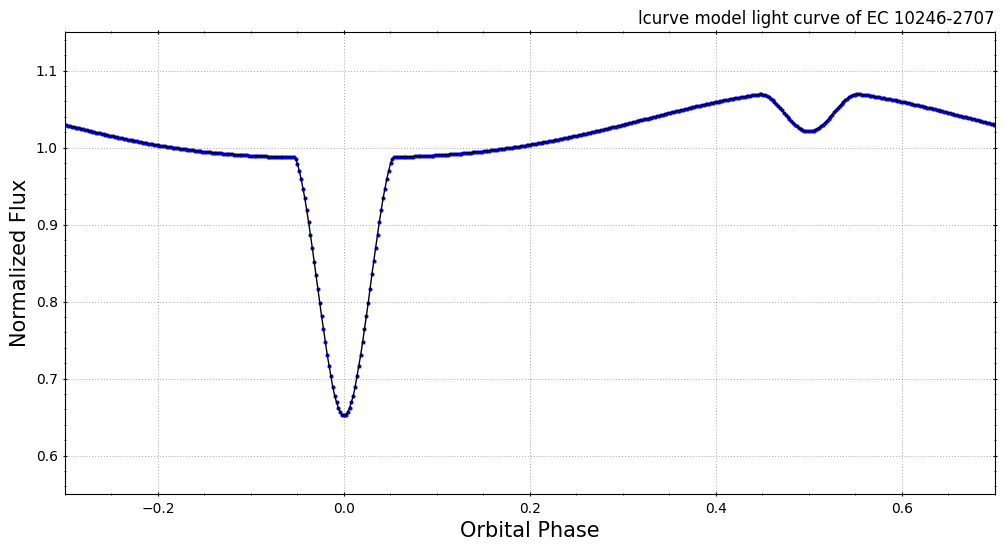

In [6]:
# Since Barlow+2013 plots their light curve in phase, we'll do the same.

# Clone the existing model to copy its parameters.
hires_model = model.clone()

# Update the period and t0 values into phase values.
hires_model.parameters.t0.value = 0.0
hires_model.parameters.period.value = 1.0

# Generate high resolution time and phase grids to sample the model at.
model_phase = np.linspace(0.0, 1.0, 500)
model_times = model_phase * model.parameters.period.value + model.parameters.t0.value

# Assign the time grid data to our high-res model object
hires_model.set_data(model_times)

# Run lroche on the hires_model to extract model_flux (providing model_phase data since we're plotting in phase later).
# scale=False returns B-lambda flux units.
hires_model_flux = hires_model.lroche(data=model_phase, scale=False)["model_flux"]

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)

ax.scatter(model_phase, hires_model_flux/np.mean(hires_model_flux), color='blue', marker='.', s=15, linestyle='None',)
ax.scatter(model_phase-1.0, hires_model_flux/np.mean(hires_model_flux), color='blue', marker='.', s=15, linestyle='None',)

ax.plot(model_phase, hires_model_flux/np.mean(hires_model_flux), color='black', linewidth=1.0, zorder=9)
ax.plot(model_phase-1.0, hires_model_flux/np.mean(hires_model_flux), color='black', linewidth=1.0, zorder=9)

ax.set_xlim(-0.3, 0.7)
ax.set_ylim(0.55, 1.15)
ax.set_xlabel("Orbital Phase", fontsize=15)
ax.set_ylabel("Normalized Flux", fontsize=15)

ax.minorticks_on()
ax.grid(linestyle=':', color='black', alpha=0.3)
ax.tick_params(top=True, which='both', right=True, direction='inout')

ax.set_title("lcurve model light curve of EC 10246-2707", loc='right');
plt.show()

#

---
## Compare our model light curve to the B-band lightcurve of EC 10246-2707 from Figure 5 in Barlow+2013:

<img src="tutorial_images/barlow2013_fig5.jpeg" width=960 height=463 />

---

### For fun, let's create a model without irradiation by setting the "absorb" parameter to 0.0 to see how it affects the light curve shape.

The absorb parameter controls the fraction of irradiating bolometric flux that is absorbed and re-emitted ("reflected" light). This value should be between 0 and 1.

This demonstrates how we can use the Jupyter notebook to quickly compare models with different parameters.

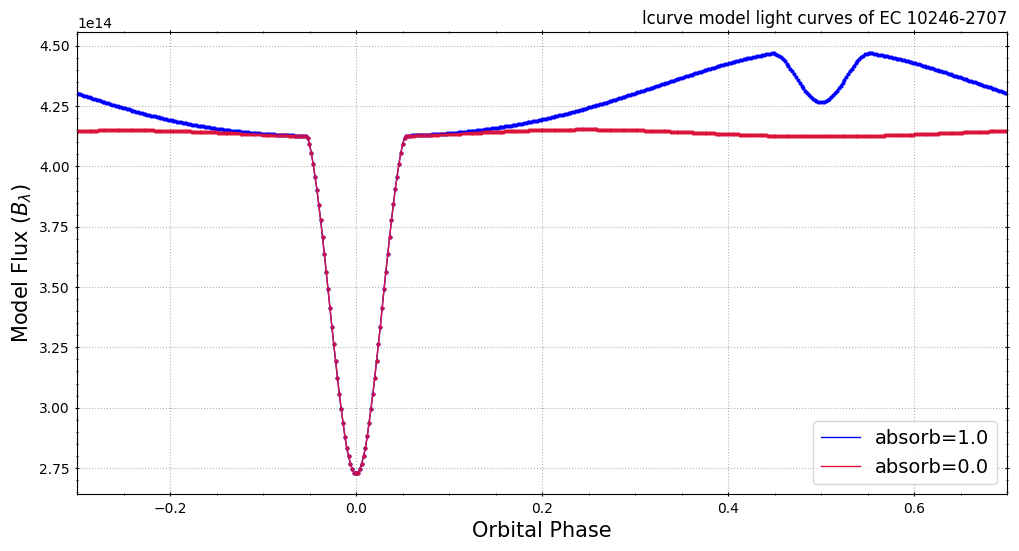

In [7]:
# Clone the hires model of EC 10246-2707 and change only the absorb parameter:
hires_model_no_absorb = hires_model.clone()
hires_model_no_absorb.parameters.absorb.value = 0.0

# Run lroche to extract model_flux.
# Manually provide data=model_phase again to match the absorb model.
hires_model_flux_no_absorb = hires_model_no_absorb.lroche(data=model_phase, scale=False)["model_flux"]

fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)

ax.scatter(model_phase, hires_model_flux, color='blue', marker='.', s=15, linestyle='None',)
ax.scatter(model_phase-1.0, hires_model_flux, color='blue', marker='.', s=15, linestyle='None',)

ax.plot(model_phase, hires_model_flux, color='blue', linewidth=1.0, zorder=9, label=f"absorb={hires_model.parameters.absorb.value:.1f}")
ax.plot(model_phase-1.0, hires_model_flux, color='blue', linewidth=1.0, zorder=9)

ax.scatter(model_phase, hires_model_flux_no_absorb, color='crimson', marker='.', s=15, linestyle='None',)
ax.scatter(model_phase-1.0, hires_model_flux_no_absorb, color='crimson', marker='.', s=15, linestyle='None',)

ax.plot(model_phase, hires_model_flux_no_absorb, color='crimson', linewidth=1.0, zorder=9, label=f"absorb={hires_model_no_absorb.parameters.absorb.value:.1f}")
ax.plot(model_phase-1.0, hires_model_flux_no_absorb, color='crimson', linewidth=1.0, zorder=9)

ax.set_xlim(-0.3, 0.7)
# ax.set_ylim(0.55, 1.15)
ax.set_xlabel("Orbital Phase", fontsize=15)
ax.set_ylabel(r"Model Flux ($B_\lambda$)", fontsize=15)

ax.minorticks_on()
ax.grid(linestyle=':', color='black', alpha=0.3)
ax.tick_params(top=True, which='both', right=True, direction='inout')
ax.legend(fontsize=14, loc="lower right")

ax.set_title("lcurve model light curves of EC 10246-2707", loc='right');
plt.show()

#

# Generating realistic light curves using <span style="font-family:Courier">lroche</span>

We now know how to generate a clean model light curve from a set of binary parameters using <span style="font-family:Courier">lroche</span>. This method can be applied to generate an arbitrary number of light curves with various sampling, noise levels, and binary parameters. These can be used to test limits of observations, such as
<ul>
    <li>What is my detection efficiency for ultra-compact binaries with signal to noise level __ if I sample with __-minute cadence?
        <ul><li>How many binaries would I fail to detect with a specific observing setup?</li></ul>
    </li>
    <li>At what inclination angle would my binary no longer show detectable eclipses with signal to noise __?</li>
    <li>What signal to noise level do I need to obtain __% uncertainties on my fitted parameters?
        <ul><li>Potentially useful for estimating exposure time requirements for telescope proposals</li></ul>
    </li>
    <li>. . . or any other observational astronomy question you may want answered.</li>
</ul>

---

To continue with the lcurve tutorial, we'll need to generate a more realistic light curve. To do this, we can reuse our previous lroche command and simply increase the "noise" parameter to our desired noise level, measured as RMS scatter to the scaled model light curve. However, for this tutorial we'll build a noisy model light curve by using python to add noise to our noiseless model light curve.

In [8]:
# Define sampling parameters
snr = 100                                    # Signal to noise ratio
snr_sigma = 0.10                             # Fractional scatter in signal to noise used to approximate different errorbar sizes as observing conditions vary.
exptime = 30                                 # Exposure time in seconds
readout_time = 10                            # Read out time in seconds
dead_time = 0                                # Total dead time from other sources (cycling between fields for survey telescopes)
cadence = exptime + readout_time + dead_time # Barlow+2013 used a cycle time of 40 seconds for their B-band light curve, so we use cadence = 40 seconds
total_observing_time = 3.7*3600              # (seconds) Barlow+2013 spent 3.7 hours on their object on their first night, so we use 3.7 hours here.


# We can conveniently and efficiently sample it using a CubicSpline interpolation with periodic boundary conditions
model_lc = CubicSpline(model_times, hires_model_flux, bc_type="periodic")

#

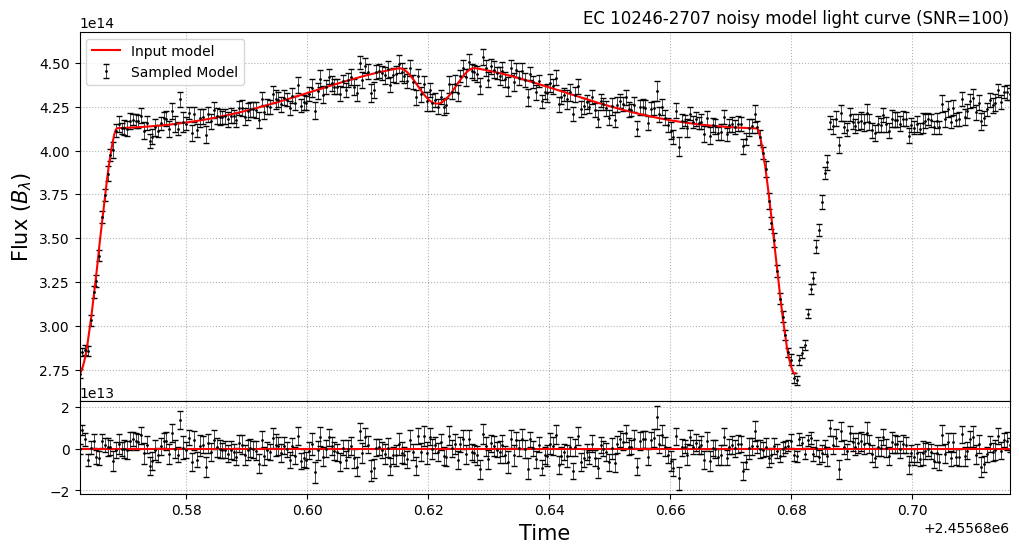

In [9]:
# Create a function for sampling a model light curve.
def take_image(time_start, exptime, model_lc, snr, snr_sigma):
    '''
    Simulate obtaining a single image exposure at a specific time.

    Inputs:
    time_start:   Time of exposure start                               (days)
    exptime:      Total integration time for the exposure              (days)
    model_lc:     CubicSpline output for interpolation.                (time:days, flux/mag)
                  Shape: (2,10000); two columns: [time, flux OR mag]
    snr:          Desired signal to noise ratio for the output         (dimensionless)

    Outputs:
        [time, flux, error] : list
                              single-observation
    '''
    snr_obs = snr*np.random.lognormal(0, snr_sigma)

    times = np.linspace(time_start, time_start + exptime, 300)
    flux_true = np.trapezoid(model_lc(times), times) / exptime    
    
    flux_obs_error = flux_true / snr_obs
    flux_obs = flux_true + np.random.normal(0, flux_obs_error)
    
    time = time_start + exptime/2
    
    return time, flux_obs, flux_obs_error


# Start with empty lists representing our measured times, fluxes, and flux errors.
time, flux, flux_error = [[] for k in range(3)]

# Begin taking single exposures until we have observed for "total_observing_time"
elapsed_time = 0
while elapsed_time < total_observing_time:
    observations = take_image(model.parameters.t0.value + elapsed_time/86400, exptime/86400, model_lc, snr, snr_sigma)
    time.append(observations[0])
    flux.append(observations[1])
    flux_error.append(observations[2])
    elapsed_time += cadence
    
# Build a DataFrame of our artificial observations.
df_data_noise = pd.DataFrame({"time":time,
                              "exptime":exptime/86400,
                              "flux":flux,
                              "flux_error":flux_error,
                              "weight":1.0,
                              "ndiv":1.0
                             })

# Plot the noisy and noiseless model light curves together.
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(5,1,(1,4))

ax.errorbar(df_data_noise["time"], df_data_noise["flux"], yerr=df_data_noise["flux_error"], color='black', marker='.', markersize=2, linestyle='None', capsize=2, elinewidth=0.5, label="Sampled Model")
ax.plot(model_times, hires_model_flux, color='red', label="Input model")

ax.set_ylabel(r"Flux ($B_\lambda$)", fontsize=15)
# ax.set_ylim(0.55, 1.15)
ax.grid(linestyle=':', color='black', alpha=0.3)
ax.legend();

ax2 = fig.add_subplot(5,1,5)
ax2.errorbar(df_data_noise["time"], df_data_noise["flux"]-model_lc(df_data_noise["time"]), yerr=df_data_noise["flux_error"], color='black', marker='.', markersize=2, linestyle='None', capsize=2, elinewidth=0.5)
ax2.plot(df_data_noise["time"], np.zeros_like(df_data_noise["time"]), color='red')
ax2.set_xlabel("Time", fontsize=15)

ax.set_xlim(min(df_data_noise["time"]), max(df_data_noise["time"]))
ax2.set_xlim(min(df_data_noise["time"]), max(df_data_noise["time"]))
ax2.grid(linestyle=':', color='black', alpha=0.3)

ax.set_title(f"EC 10246-2707 noisy model light curve (SNR={snr})", loc='right')
plt.subplots_adjust(hspace=0)

#

# Parameter estimation with <span style="font-family:Courier">lroche</span>:
## The first step of lcurve: Estimating the first guess parameters of your system "by-eye"

To determine the best-fitting parameters that describe the light curve, lcurve will use Markov Chain Monte Carlo (MCMC) methods to explore the parameter space around the given initial values. This means we must have decent starting values or the MCMC sampler may fail to find the global minimum (or even fail converge to a solution at all).

We begin by estimating the system parameters by-eye. After we have a decent by-eye fit, we use the command <span style="font-family:Courier">simplex</span> (similar to <span style="font-family:Courier">lroche</span>) to refine our parameters through a fitting algorithm.

### Applying educated guessing for initial parameter values based on expected and literature values

To find "good enough" starting values, we will manually adjust the parameters until we find a model light curve that roughly matches the observed data in a simple plot. If we know nothing about our system, then we should start with typical values from the literature for systems that are similar to what we expect ours to be. Our light curve is clearly an HW Vir type, so we expect a hot subdwarf primary. <u><a href=https://ui.adsabs.harvard.edu/abs/2022A%26A...666A.182S/abstract>Schaffenroth+2022</a></u> provides observational properties to hot subdwarfs in close binaries, so we can estimate our values from their Tables A1 and A2.

In this example, we'll assume that we have spectroscopic follow-up data for our system, using the values from Barlow+2013. These prior observations provide the surface gravity ($\log{g_1}=5.64\pm0.02$), effective temperature ($T_{\rm eff,1}=28,900\pm400~{\rm K}$), and velocity semi-amplitude ($K_1=71.6\pm1.7~{\rm km~s^{-1}}$) of the primary star. Additionally, our newly acquired light curve provides the orbital period ($P_{\rm orb}=0.01185079936~{\rm d}$), the time of primary conjunction ($T_0=2455680.562160~{\rm d}$), evidence for deep eclipses ($i\approx80-90~{\rm deg}$), and evidence for a strong reflection effect (the albedo of the companion is close to 1.0). We will add these values to our model:
><span style="font-family:Courier">
>iangle = 85<br/>
>t1 = 28900<br/>
>beam_factor1 = 1.67 (using calc_beam.py with "t1" and the filter wavelength)<br/>
>period = 0.1185079936<br/>
>tperiod = 0.1185079936<br/>
>t0 = 2455680.562160<br/>
>absorb = 1.0<br/>
></span>

If we assume that this binary is a typical HW Vir, then we expect a hot subdwarf primary star. A typical hot subdwarf will have $M_{\rm sdB}\approx0.47~{\rm M_\odot}$. Using our estimates on $K_1$, $P_{\rm orb}$, $M_1$, and $i$, we can use the <u><a href=https://en.wikipedia.org/wiki/Binary_mass_function>binary mass function</a></u> to estimate the mass of the companion, $M_2$. A quick calculation tells us that $M_2$ would range from $0.116~{\rm M_\odot}$ to $0.113~{\rm M_\odot}$, for inclinations between $80~{\rm deg}$ and $90~{\rm deg}$. For simplicity, we take $M_2=0.115~{\rm M_\odot}$, which gives us mass ratio $q=\frac{M_2}{M_1}=\frac{0.115}{0.470}=0.24$. Kepler's laws then tell us the orbital separation is $a\approx0.85~{\rm R_\odot}$. Similarly, the mass and velocity of the primary with the mass ratio provides the velocity of the companion ($q=\frac{M_2}{M_1}=\frac{K_1}{K_2}$; $K_2\approx298~{\rm km~s^{-1}}$). The <span style="font-family:Courier">velocity_scale</span> parameter is the sum of orbital speeds ($\frac{K_1+K_2}{\sin{i}}$), so we can add the following to our model:

><span style="font-family:Courier">
>q = 0.24<br/>
>velocity_scale = 371<br/>
></span>

A reasonable temperature for an M-type star is $T_{\rm eff,2}\approx3000~{\rm K}$. <u><a href=https://ui.adsabs.harvard.edu/abs/2019A%26A...626A..32C/abstract>Cassisi+2019</a></u> provides a simple relationship between M-dwarf temperature and radius. If we assume $T_2=3000~{\rm K}$, then its radius would be $R_2\approx0.172~{\rm R_\odot}$, which corresponds to a scaled radius $r_2=\frac{R_2}{a}=\frac{0.172}{0.85}\approx0.20$. For the radius of the hot subdwarf, Schaffenroth+2022 Table A1 provides radius measurements for hot subdwarfs in HW Vir binaries. The average value from this table is $R_{\rm HW Vir}=0.187~{\rm R_\odot}$, which corresponds to scaled radius $r_1=\frac{R_1}{a}=\frac{0.187}{0.85}\approx0.22$.  We further update our model with:

><span style="font-family:Courier">
>r1 = 0.22<br/>
>r2 = 0.20<br/>
>t2 = 3000<br/>
>beam_factor2 = 10.97 (using calc_beam.py with "t2" and the filter wavelength)<br/>
></span>

Note that we could also obtain a direct measurement of the radius of the primary star if we have a precise <em>Gaia</em> parallax and a well-sampled SED fit.

Finally, we would need to find up-to-date values for limb-darkening and gravity-darkening coefficients for hot subdwarfs and M-dwarfs. For white dwarfs, the go-to is <u><a href=https://ui.adsabs.harvard.edu/abs/2020A%26A...634A..93C/abstract>Claret+2020</a></u>. For main sequence stars, it is <u><a href=https://ui.adsabs.harvard.edu/abs/2023A%26A...674A..63C/abstract>Claret+2023</a></u>. For this example, we will use the values in Barlow+2013 Table 3. Note that gravity darkening values should not matter for spherical stars, since its effects depend on the local gravity, which should be the same everywhere for spherical stars.

><span style="font-family:Courier">
>ldc1_1 = 0.260<br/>
>ldc1_2 = 0<br/>
>ldc1_3 = 0<br/>
>ldc1_4 = 0<br/>
>ldc2_1 = 0.601<br/>
>ldc2_2 = 0<br/>
>ldc2_3 = 0<br/>
>ldc2_4 = 0<br/>
>gravity_dark1 = 1.00<br/>
>gravity_dark2 = 0.32<br/>
></span>


Based only on rough (but realistic) estimates, we have our first-guess model ready to test. We will now update our model, use <span style="font-family:Courier">lroche</span> to generate a model light curve, and plot the model with the data together with Matplotlib.

End of file reached.
134 lines read from parameters_files/parameters_default_i.txt


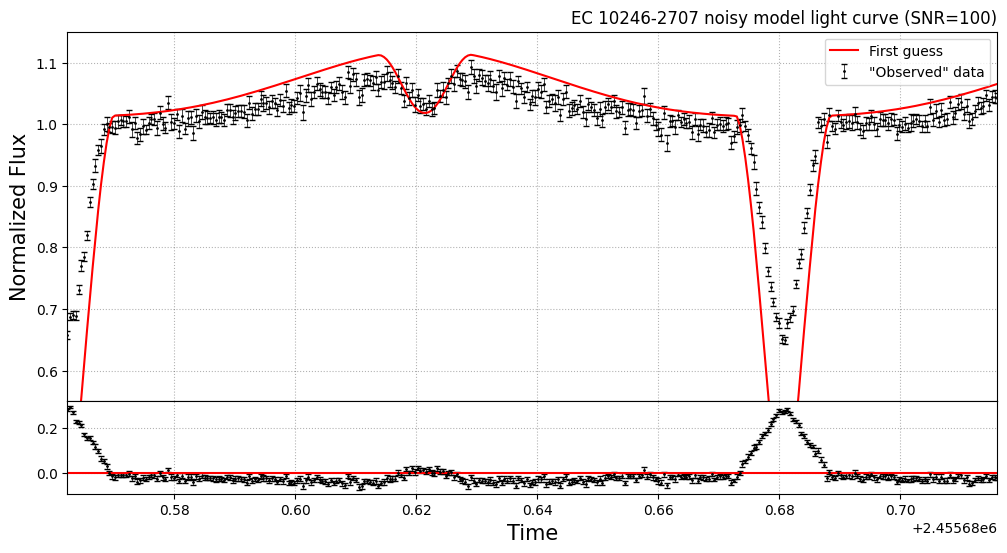

In [10]:
# Generate a new Lcurve_model object.
model_guess = Lcurve_model(parameters_file="parameters_files/parameters_default_i.txt")

# Scale the artificial data by its mean value and assign the data to the model.
df_data_noise["flux_error"] /= df_data_noise["flux"].mean()
df_data_noise["flux"] /= df_data_noise["flux"].mean()
model_guess.set_data(data=df_data_noise)

# Update the parameters based on our first-guess estimates above.
model_guess.parameters.iangle.value = 85
model_guess.parameters.t1.value = 28900
model_guess.parameters.beam_factor1.value = 1.67
model_guess.parameters.period.value = 0.1185079936
model_guess.parameters.t0.value = 2455680.562160
model_guess.parameters.absorb.value = 1.0

model_guess.parameters.q.value = 0.24
model_guess.parameters.velocity_scale.value = 371

model_guess.parameters.r1.value = 0.22
model_guess.parameters.r2.value = 0.20
model_guess.parameters.t2.value = 3000
model_guess.parameters.beam_factor2.value = 10.97

model_guess.parameters.ldc1_1.value = 0.260
model_guess.parameters.ldc1_2.value = 0.0
model_guess.parameters.ldc1_3.value = 0.0
model_guess.parameters.ldc1_4.value = 0.0
model_guess.parameters.ldc2_1.value = 0.601
model_guess.parameters.ldc2_2.value = 0.0
model_guess.parameters.ldc2_3.value = 0.0
model_guess.parameters.ldc2_4.value = 0.0
model_guess.parameters.gravity_dark1.value = 1.00
model_guess.parameters.gravity_dark2.value = 0.32

model_guess.parameters.tperiod = 0.1185079936
model_guess.parameters.wavelength = 436.953

# Run lroche to generate a light curve
guess_lroche_output = model_guess.lroche(scale=True)

# Plot the model light curve with the data
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(5,1,(1,4))

ax.errorbar(df_data_noise["time"], df_data_noise["flux"], yerr=df_data_noise["flux_error"], color='black', marker='.', markersize=2, linestyle='None', capsize=2, elinewidth=0.5, label="\"Observed\" data")
ax.plot(df_data_noise["time"], guess_lroche_output["model_flux"], color='red', label="First guess")

ax.set_ylabel("Normalized Flux", fontsize=15)
ax.set_ylim(0.55, 1.15)
ax.grid(linestyle=':', color='black', alpha=0.3)
ax.legend();

ax2 = fig.add_subplot(5,1,5)
ax2.errorbar(df_data_noise["time"], df_data_noise["flux"]-guess_lroche_output["model_flux"], yerr=df_data_noise["flux_error"], color='black', marker='.', markersize=2, linestyle='None', capsize=2, elinewidth=0.5)
ax2.plot(df_data_noise["time"], np.zeros_like(df_data_noise["time"]), color='red')
ax2.set_xlabel("Time", fontsize=15)

ax.set_xlim(min(df_data_noise["time"]), max(df_data_noise["time"]))
ax2.set_xlim(min(df_data_noise["time"]), max(df_data_noise["time"]))
ax2.grid(linestyle=':', color='black', alpha=0.3)

ax.set_title(f"EC 10246-2707 noisy model light curve (SNR={snr})", loc='right')
plt.subplots_adjust(hspace=0)

#

### Manually adjusting parameters until you have a "good enough" by-eye fit.

Our first guess model has the correct shape, but the eclipse durations are slightly too long and the primary eclipse is too deep. To decrease the eclipse depth, we could:
<ol>
    <li>Adjust the inclination angle</li>
    <li>Adjust temperatures
        <ul><li>but our spectroscopic fit is assumed to be robust</li></ul>
    </li>
    <li>Adjust our radius estimates
        <ul><li>but adjusting radii will also affect the eclipse duration</li></ul>
    </li>
</ol>
In this case, the inclination angle is the best option for adjusting the model eclipse depth. To speed this up, we'll generate a few more models, only changing the inclination angle, and plot them all together.

It is important that we do not change more than one parameter at the same time. Doing so almost always leads to confusion on which parameter caused the changes.

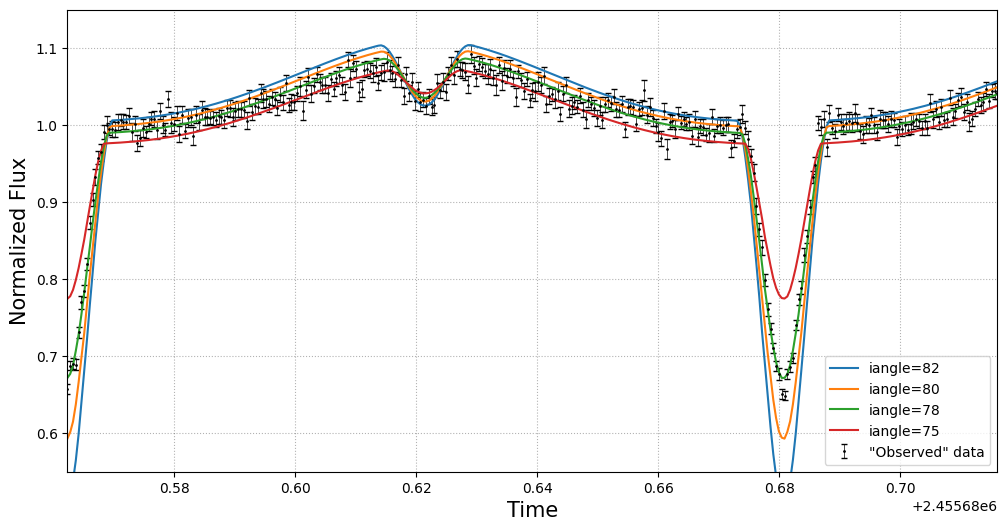

In [11]:
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(111)

# Plot the observed data
ax.errorbar(df_data_noise["time"], df_data_noise["flux"], yerr=df_data_noise["flux_error"], color='black', marker='.', markersize=2, linestyle='None', capsize=2, elinewidth=0.5, label="\"Observed\" data")

# Loop over new test inclinations, create a new parameters.txt file for each, then plot the model.
test_iangle = [82, 80, 78, 75]
for inclination_angle in test_iangle:

    model_i = model_guess.clone()
    model_i.parameters.iangle.value = inclination_angle

    model_i_flux = model_i.lroche()["model_flux"]
    
    ax.plot(df_data_noise["time"], model_i_flux, label=f"iangle={inclination_angle}")


ax.set_ylabel("Normalized Flux", fontsize=15)
ax.set_ylim(0.55, 1.15)
ax.grid(linestyle=':', color='black', alpha=0.3)
ax.legend();

ax.set_xlabel("Time", fontsize=15)

ax.set_xlim(df_data_noise["time"].min(), df_data_noise["time"].max())
plt.subplots_adjust(hspace=0)

#

#### The best eclipse depth appears to fall between the <span style="font-family:Courier">iangle=78</span> and <span style="font-family:Courier">iangle=80</span> models, so we'll use <span style="font-family:Courier">iangle=79</span> as our starting point for automatic refinement.

---

# Refining starting parameters for lcurve MCMC:
## Fitting data with <span style="font-family:Courier">simplex</span>

We'll use the <span style="font-family:Courier">simplex</span> command to refine our model parameters further through a "simplex" fitting algorithm.
> <em>The minimisation uses the simplex method via the Numerical Recipes routine 'amoeba' which works with a group of N+1 points in N dimensional space and moves the points around to move downhill in chi\*\*2. It is slow but robust.</em> (see <u>https://github.com/trmrsh/cpp-lcurve/blob/master/src/simplex.cc</u>)

### The parameters file revisited.

The <span style="font-family:Courier">simplex</span> command reads values from the parameters file to determine which parameters should be fixed and which should be allowed to vary (and by roughly how much). As a reminder, the column values following the "=" in the parameters file describe the values and flags used by the fit for each parameter. For example, the row for orbital inclination may show:<br/>

>&nbsp;&nbsp;&nbsp;&nbsp;<span style="font-family:Courier">iangle = 85 1 0.1 0 1</span><br/>

<ol>
    <li>The first column (<span style="font-family:Courier">85</span>) is the value for the parameter.</li>
    <li>The second column (<span style="font-family:Courier">1</span>) is the range over which to vary the parameter (if allowing it to vary) for <span style="font-family:Courier">simplex</span> ($85\pm1$)</li>
    <li>The third column (<span style="font-family:Courier">0.1</span>) is the step size used to compute numerical derivatives.
        <ul><li>only used with the <span style="font-family:Courier">levmarq</span> command, which is a "least-squares" version of the <span style="font-family:Courier">simplex</span> command.</li></ul>
    </li>
    <li>The fourth column (<span style="font-family:Courier">0</span>) is the flag to allow (1=True) or disallow (0=False) the parameter to vary in the fit.</li>
    <li>The fifth column (<span style="font-family:Courier">1</span>) is the flag to enable (1=True) or disable (0=False) the parameter entirely from the fit (essentially disabling the physics behind it)
        <ul><li>This value was introduced to enable/disable the star spot parameters. I'm not sure if it applies to all parameters.</li></ul></li>
</ol> 
If we want to refine our model by fitting a parameter, then we need to set the fourth column of that parameter to <span style="font-family:Courier">1</span> and adjust the second column value to a reasonable range to vary the parameter over. In this case, let's refine the mass ratio, inclination angle, primary and secondary radii, secondary temperature, and time of primary conjunction. We'll change our parameters file to have the following lines (note the "<span style="font-family:Courier">1 1</span>" at the end of each line):<br/>

><span style="font-family:Courier">
>&nbsp;&nbsp;&nbsp;&nbsp;q = 0.24 0.01 0.0001 1 1<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;iangle = 79 1 0.1 1 1<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;r1 = 0.22 0.01 0.0001 1 1<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;r2 = 0.20 0.01 0.0003 1 1<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;t0 = 2455680.562160 0.00002 0.000002 1 1 <br/>
></span>
<br/>

Up until now, we have been assigning parameter values to our Lcurve_model objects using the model.parameters.{name}.value format. We can also use this method to adjust the other columns:
<ul>
    <li><span style="font-family:Courier">model.parameters.{name}.value</span></li>
    <li><span style="font-family:Courier">model.parameters.{name}.range</span></li>
    <li><span style="font-family:Courier">model.parameters.{name}.dstep</span></li>
    <li><span style="font-family:Courier">model.parameters.{name}.vary</span></li>
    <li><span style="font-family:Courier">model.parameters.{name}.defined</span></li>
</ul>

After updating our model, we can use <span style="font-family:Courier">model.create_parameters_file()</span> to create a new parameters file for use with <span style="font-family:Courier">simplex</span>, which will need to be run using the terminal commands, similar to <span style="font-family:Courier">lroche</span>.

In [12]:
model_guess.parameters.q.vary = True
model_guess.parameters.q.range = 0.01

model_guess.parameters.iangle.value = 79.0
model_guess.parameters.iangle.vary = True
model_guess.parameters.iangle.range = 1.0

model_guess.parameters.r1.vary = True
model_guess.parameters.r1.range = 0.01

model_guess.parameters.r2.vary = True
model_guess.parameters.r2.range = 0.01

model_guess.parameters.t2.vary = True
model_guess.parameters.t2.range = 500

---
## The <span style="font-family:Courier">simplex</span> command
Similar to <span style="font-family:Courier">lroche</span>, <span style="font-family:Courier">simplex</span> takes 5 parameters in a specific order:
<ol>
    <li>Parameter file (<span style="font-family:Courier">MODEL</span>)</li>
    <li>Light curve data file (<span style="font-family:Courier">DATA</span>)</li>
    <li>Chi-squared convergence fraction threshold (<span style="font-family:Courier">FTOL</span>)
        <ul><li>The fractional change in chi-squared between iterations that defines model convergence.</li> 
            <li>0.01 or 0.001 are typically good enough as 1% and 0.1% fractional improvement between iterations.</li></ul>
    </li>
    <li>Maximum number of evaluations to run (<span style="font-family:Courier">NMAX</span>)</li>
    <li>Output file name (<span style="font-family:Courier">OUTPUT</span>)
    <ul><li>The output file is a new "parameters file" containing the resulting best-fitting parameters for each fitted parameter.</li></ul>
    </li>
</ol>

---

You may run <span style="font-family:Courier">simplex</span> by simply typing the command "<span style="font-family:Courier">simplex</span>" without any additional arguments. This will prompt you for each required argument individually.
<ol>
    <li><span style="font-family:Courier">simplex</span>
        <ul>
            <li><span style="font-family:Courier">MODEL - input model file</span></li>
            <li><span style="font-family:Courier">DATA - data file (time, exposure, flux, error, weight, ndiv)</span></li>
            <li><span style="font-family:Courier">FTOL - fractional tolerance for convergence</span></li>
            <li><span style="font-family:Courier">NMAX - maximum number of model evaluations</span></li>
            <li><span style="font-family:Courier">OUTPUT - output model file</span></li>
        </ul>
    </li>
</ol>
    
Alternatively, you may type "<span style="font-family:Courier">simplex</span>" followed by every additional argument in order. This method will skip the prompts. 
<ol start="2">  
    <li><span style="font-family:Courier">simplex MODEL DATA FTOL NMAX OUTPUT</span></li>
</ol>

<span style="font-family:Courier">simplex</span> is usually pretty quick to run, but it could take a few seconds or a few minutes or even tens of minutes to complete depending on your inputs. The <em>levmarq</em> is not covered in this tutorial, but it usually takes longer to run.

#### Note that our python wrapper version does not yet support simplex, but we can use scipy.optimize.minimize() with the model.lroche()["chisq"] output and have the same effect. For this tutorial, we continue by running simplex using subprocess.Popen()

### Important note on runtime:
Arguably the most important parameters defining the runtime of <span style="font-family:Courier">lroche</span>, <span style="font-family:Courier">simplex</span>, and <span style="font-family:Courier">levmarq</span> are those parameters defining the resolution of the stellar surface grids for each source of flux in your model:
<ul>
    <li><span style="font-family:Courier">nlat1f = 100</span></li>
    <li><span style="font-family:Courier">nlat2f = 100</span></li>
    <li><span style="font-family:Courier">nlat1c = 100</span></li>
    <li><span style="font-family:Courier">nlat2c = 100</span></li>
    <li><span style="font-family:Courier">nrad = 100</span></li>
    <li><span style="font-family:Courier">nspot = 100</span></li>
</ul>

These parameters are found near the bottom of the parameters file and control how many surface element points make up each flux-contributing component of the system (star1, star2, accretion disk, accretion bright spot). With larger numbers, you will create more complete surface grid and have a more detailed/smooth light curve model, but at the cost of increased runtime. If you have a system with many sharp features, then you may want larger numbers to allow your model to capture those features. These parameters are described with the other parameters in the <u><a href=https://github.com/trmrsh/cpp-lcurve/blob/master/src/lroche.cc#L271>lroche.cc</a></u> file on the official Github.

For simplicity, try to keep the "fine" and "coarse" grids the same (<span style="font-family:Courier">nlat1f=nlat1c</span>). I have modified our verison of lcurve using a few shortcuts and believe that some unexpected/unseen numerical issues may (or may not) arise if the "fine" and "coarse" grids are not the same resolution (<span style="font-family:Courier">nlat1f=nlat1c</span>  and  <span style="font-family:Courier">nlat2f=nlat2c</span>) when using the new features (the old features should be unaffected). I recommend keeping these parameters all between 50-100 unless you have a good reason to increase it further. Going above 150-200 is almost certainly not needed and will result in a very slow fit to your data for no benefit.

## Running <span style="font-family:Courier">simplex</span>: the output

In [13]:
# We build our simplex command for 0.1% convergence threshold and up to 400 iterations
# Since we're running this from the command line, we need to provide a new parameters file and data file separately.

# Automatically create a new parameters file from our model directly.
simplex_input_parameters_filename = model_guess.create_parameters_file("parameters_files/simplex_input_example.txt")


# Export the artificial data to a new light curve file.
simplex_output_parameters_filename = "parameters_files/parameters_simplex_V.txt"
noisy_data_filename = "data_files/ec10246-2707_noise_model_V.txt"
df_data_noise.to_csv(noisy_data_filename, sep=" ", index=False, header=False)


# Build the simplex command
ftol = 0.01
niter = 400
cmd = f"simplex {simplex_input_parameters_filename} {noisy_data_filename} {ftol} {niter} {simplex_output_parameters_filename}"
print(f"Running command:\n  {cmd}")

# Run simplex with Popen()
output, error = subprocess.Popen(cmd.split(), stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True).communicate()

print("Output:")
print("="*20)
print(output)
print(error)
print("="*20)


# Create a new Lcurve_model object using the new parameters file that came from the simplex output
model_simplex = Lcurve_model(parameters_file=simplex_output_parameters_filename)


# Print the updated best-fitting parameters:
print("Parameters updated: ")
print("="*60)
for parameter_name in dir(model_guess.parameters):
    if parameter_name.startswith("_"):
        continue

    value_guess = getattr(model_guess.parameters, parameter_name)
    value_simplex = getattr(model_simplex.parameters, parameter_name)

    if hasattr(value_guess, "value"):
        if value_guess.vary:
            print(f"{parameter_name:<15s}: {value_guess.value}  ->  {value_simplex.value}")
print("="*60)
print()

#

Running command:
  simplex parameters_files/simplex_input_example.txt data_files/ec10246-2707_noise_model_V.txt 0.01 400 parameters_files/parameters_simplex_V.txt
Output:
simplex.cc recompiled on Aug  3 2026 at 14:27:18
End of file reached.
333 lines of data read from data_files/ec10246-2707_noise_model_V.txt

Weighted chi**2 = 1362.33312401, scale factor = 2.04014988627e-15, neval = 1, wnok = 333
Weighted chi**2 = 823.014128022, scale factor = 1.96036709737e-15, neval = 7, wnok = 333
Weighted chi**2 = 605.131115416, scale factor = 1.93723291648e-15, neval = 9, wnok = 333
Weighted chi**2 = 598.304369798, scale factor = 1.94686210885e-15, neval = 16, wnok = 333
Weighted chi**2 = 525.44389177, scale factor = 2.03580831124e-15, neval = 20, wnok = 333
Weighted chi**2 = 504.378790744, scale factor = 2.09562610235e-15, neval = 21, wnok = 333
Weighted chi**2 = 482.486580426, scale factor = 2.09898062419e-15, neval = 22, wnok = 333
Weighted chi**2 = 477.029416449, scale factor = 2.19203836097e

End of file reached.
134 lines read from parameters_files/parameters_simplex_V.txt


---

The in-progress output from our <span style="font-family:Courier">simplex</span> fit is displayed above. When run from the terminal, it displays each output line in real-time.

Each output line above shows the current best model's progress including:
<ul>
    <li>The weighted chi-squared value
        <ul><li>Recall that column 5 in our input light curve file is the weight for each data point. That weight value is used here</li>
        <li>The reduced chi-squared is then the chi-squared divided by the degrees of freedom</li>
        <li>A "good" fit has a reduced chi-squared close to 1.0 within the errorbars ($\chi^2_r=1.0\pm\sqrt{\frac{2}{\rm DOF}}$),<ul><li>but see: <u><a href=https://ui.adsabs.harvard.edu/abs/2010arXiv1012.3754A/abstract>Dos and don'ts of reduced chi-squared (Andrae+2010)</a></u></li></li>
        <li>If your reduced chi-squared is significantly less than 1.0, then you have likely overestimated your errorbar size (larger errorbar size than the data's scatter)</li>
        <li>If your reduced chi-squared is significantly greater than 1.0, then your model is likely not fully describing the data and/or you underestimated your errorbars (larger scatter than errorbar size).</li>
        </ul>
    </li>
    <li>The scale factor(s) used to scale the model to our data at each iteration.
        <ul><li>This scale factor can be used to overplot the model on the data properly later.</li></ul>
    </li>
    <li>The number of evaluations completed so far. This appears to be related to the NMAX (max number of evaluations) parameter.</li>
    <li>wnok (Weight.Number.OK) is the number of good data points (weight>0) used in the model.
        <ul>
            <li>Your degrees of freedom (DOF) for the fit is approximately the weighted number of data points fit (wnok) minus the number of fitted parameters (those with vary=True)</li>
        </ul>
    </li>
    <li>The filename of the saved output model parameters file.</li>
</ul>


The best-fitting parameters from <span style="font-family:Courier">simplex</span> are saved in a new parameters file, which can immediately be used with <span style="font-family:Courier">lroche</span> to generate and plot the model light curve described by the best-fitting parameters.

End of file reached.
134 lines read from parameters_files/parameters_simplex_V.txt


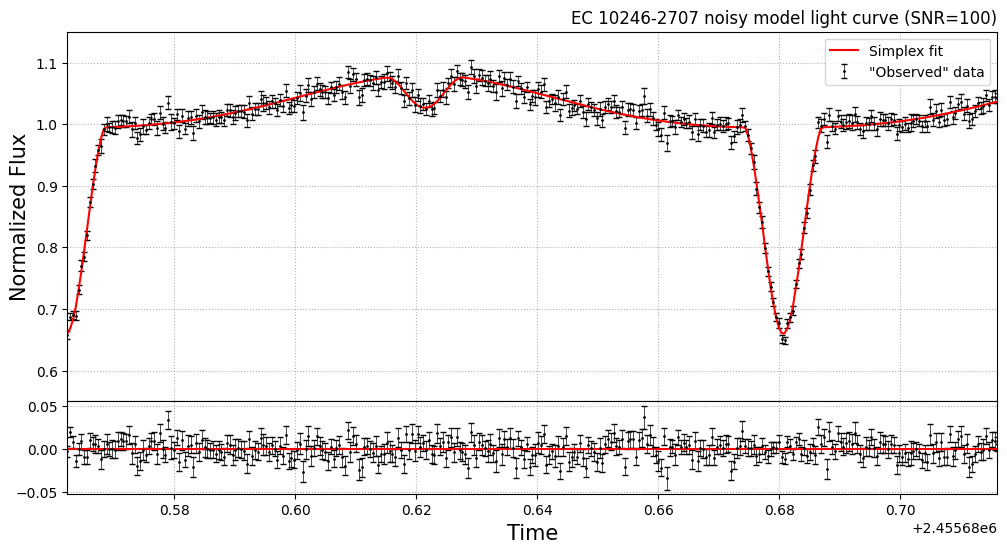

In [14]:
# Load the simplex model file as a new Lcurve_model object
simplex_model = Lcurve_model(parameters_file=simplex_output_parameters_filename)

# Run lroche on the simplex_model to extract its model_flux
simplex_model_flux = simplex_model.lroche(data=df_data_noise, scale=True)["model_flux"]

# Plot the simplex model light curve with the artificial data
fig = plt.figure(figsize=(12,6))
ax = fig.add_subplot(5,1,(1,4))

ax.errorbar(df_data_noise["time"], df_data_noise["flux"], yerr=df_data_noise["flux_error"], color='black', marker='.', markersize=2, linestyle='None', capsize=2, elinewidth=0.5, label="\"Observed\" data")
ax.plot(df_data_noise["time"], simplex_model_flux, color='red', label="Simplex fit")

ax.set_ylabel("Normalized Flux", fontsize=15)
ax.set_ylim(0.55, 1.15)
ax.grid(linestyle=':', color='black', alpha=0.3)
ax.legend();

ax2 = fig.add_subplot(5,1,5)
ax2.errorbar(df_data_noise["time"], df_data_noise["flux"]-simplex_model_flux, yerr=df_data_noise["flux_error"], color='black', marker='.', markersize=2, linestyle='None', capsize=2, elinewidth=0.5)
ax2.plot(df_data_noise["time"], np.zeros_like(df_data_noise["time"]), color='red')
ax2.set_xlabel("Time", fontsize=15)

ax.set_xlim(min(df_data_noise["time"]), max(df_data_noise["time"]))
ax2.set_xlim(min(df_data_noise["time"]), max(df_data_noise["time"]))
ax2.grid(linestyle=':', color='black', alpha=0.3)

ax.set_title(f"EC 10246-2707 noisy model light curve (SNR={snr})", loc='right')
plt.subplots_adjust(hspace=0)



### We can also visualize the 2D sky projection of the system at different orbital phases using the model.lcurve.visualize_data() command.
We put this in a Python function now for convenience later.

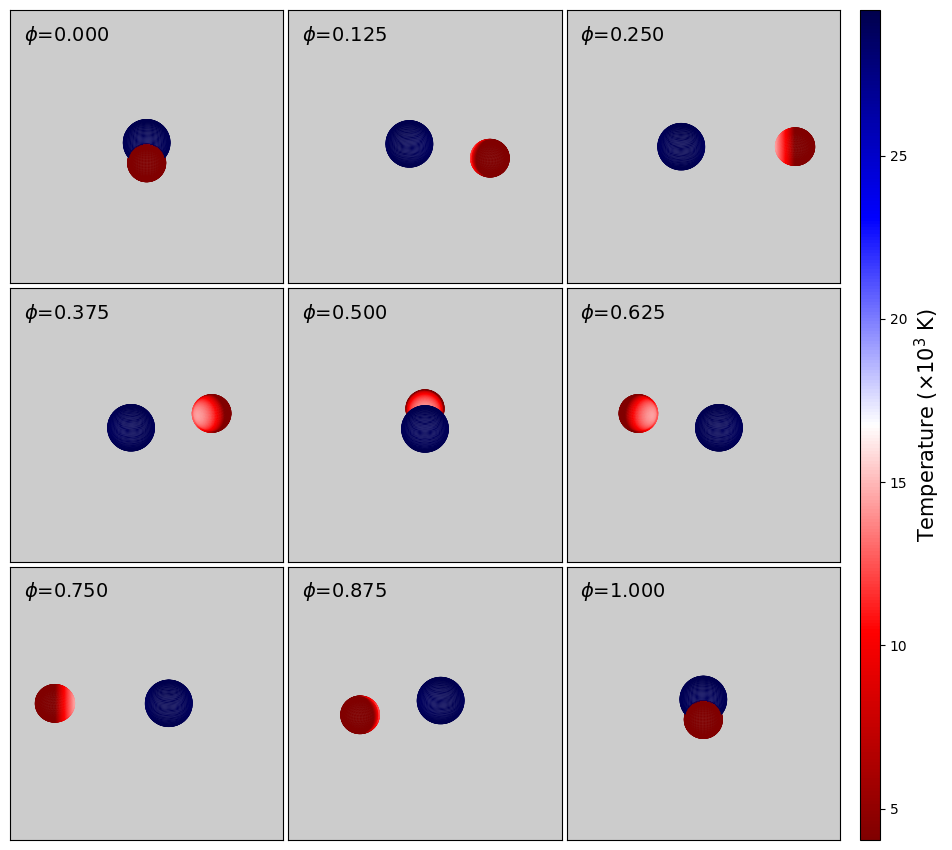

In [15]:
def plot_2d_projection(model_object, phases=np.linspace(0.0, 1.0, 9), nrows=3, ncols=3, figsize=(9,9)):
    '''
    Use model_object.visualize_data() to extract the 2D projection positions (x,y) and surface temperature for each grid point
        on each system component (star1, star2, stream, disc, outer_edge, bspot).

    Plot these, colored by surface temperature, using matplotlib in a grid plot at different orbital phases.
    Place a colorbar on the right-hand side of the plot.

    mode
    '''
    if isinstance(phases, float):
        phases = [phases]
        nrows = 1
        ncols = 1
    assert len(phases) <= nrows*ncols
        
    
    fig = plt.figure(figsize=figsize)
    
    # Overall layout parameters
    left = 0.05
    bottom = 0.05
    right = 0.88
    top = 0.95
    
    gap = 0.005 # The gap between subplots
    
    # Available space for the subplots within the full figure
    available_width = right - left
    available_height = top - bottom
    
    # Make the individual subplot panels square
    panel_size = min(
        (available_width - (ncols - 1) * gap) / ncols,
        (available_height - (nrows - 1) * gap) / nrows
    )
    
    axes = [] # Manually define subplot size/position.
    for row in range(nrows):
        for col in range(ncols):
            x = left + col * (panel_size + gap)
            y = top - (row + 1) * panel_size - row * gap
            ax = fig.add_axes([x, y, panel_size, panel_size]) # [Left-edge, Bottom-edge, x-width, y-height] in units of full figure size %
            axes.append(ax)
    
    
    # Actual dimensions of the subplot grid
    grid_height = nrows * panel_size + (nrows - 1) * gap
    
    # Bottom edge of the subplot grid
    grid_bottom = top - grid_height
    
    # Colorbar centered vertically on the subplot grid
    colorbar_left = 0.90
    colorbar_ax = fig.add_axes([colorbar_left, grid_bottom, 0.02, grid_height])
        
    all_data = []
    for phase in phases:
        visualize_output_dict = model_object.lcurve.visualize_data(phase) # Returns dictionary of surface elements: {"star1":[[xpos1, ypos1, temperature1],[xpos2, ypos2, temperature2]...]
        all_data.append(visualize_output_dict)
    
    global_temperature_list = [
        point[2]
        for visualize_output_dict in all_data
        for component in visualize_output_dict.values()
        for point in component
    ]
    vmin = min(global_temperature_list)/1000
    vmax = max(global_temperature_list)/1000
    temperature_normalization = mcolors.Normalize(vmin=vmin, vmax=vmax)
    # temperature_normalization = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    
    for i, (phase, visualize_output_dict) in enumerate(zip(phases, all_data)):
        ax = axes[i]
        ax.set_facecolor("#CCCCCC")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    
        ax.set_aspect("equal")
        ax.set_xlim(-1.2, 1.2)
        ax.set_ylim(-1.2, 1.2)
    
        ax.text(0.05, 0.95, fr"$\phi$={phase:.3f}", transform=ax.transAxes, fontsize=14, va="top")

        for name, points in visualize_output_dict.items():

            if len(points) == 0:
                continue
            grid_points = np.asarray(points)
            
            x = grid_points[:, 0]
            y = grid_points[:, 1]
            teff = grid_points[:, 2]

            scatter = ax.scatter(x, y, s=3.0, marker=".", edgecolors="none", label=name, cmap="seismic_r", c=teff/1000, norm=temperature_normalization)

    for ax in axes[len(phases):]:
        ax.set_visible(False)
    
    
    cbar = fig.colorbar(scatter, cax=colorbar_ax)
    cbar.set_label(label=r"Temperature ($\times10^3~{\rm K}$)", fontsize=15)
    plt.show()

# Create a 3x3 grid of images, with stars colored by surface temperature.
plot_2d_projection(model_simplex, phases=np.linspace(0.0, 1.0, 9), nrows=3, ncols=3, figsize=(10, 10))

### The <span style="font-family:Courier">simplex</span> model is a great fit to our data, but we're not finished.

These best-fitting <span style="font-family:Courier">simplex</span> parameters are just a good estimate for the best-fitting parameters, but does not include uncertainties. To estimate uncertainties, we run a Markov Chain Monte Carlo algorithm using Python's <span style="font-family:Courier">emcee</span> combined with <span style="font-family:Courier">lroche</span>, which will allow us to make use of our prior knowledge (constraints from spectroscopy for example) to influence the fit and derive confidence intervals for each fitted parameter.

---

# Markov Chain Monte Carlo sampling with Lcurve, using the wrapper's mcmc_wrapper.py file.

We will use Python's <span style="font-family:Courier">emcee</span> sampler for our <u><a href=https://en.wikipedia.org/wiki/Markov_chain_Monte_Carlo>Markov Chain Monte Carlo</a></u> (MCMC) sampling. <span style="font-family:Courier">emcee</span> spawns a number of "walkers" to explore parameter space and produce probability distributions of fitted parameters by using the positions of the walkers at each iteration.

The idea is simple: we use many walkers and have each one automatically run <span style="font-family:Courier">lroche</span> for a fixed set of parameters, then check its own fit's chi-squared, and then finally adjust its own model parameters between each iteration based on the results. This repeats for as many iterations as we want. The way the walkers automatically adjust their model parameters between each iteration results in the walkers spending more time in higher-probability regions and less time in lower-probability regions. We just need to give each of the walkers a good starting location, which we will base off of our <span style="font-family:Courier">simplex</span> run above.

## Lcurve MCMC inputs and outputs.

### Initial parameter ranges with the <span style="font-family:Courier">init_parameters.txt</span> file
Because each walker simply runs <span style="font-family:Courier">lroche</span> on repeat, each walker will have its own set of parameters representing its current state. We represent the full set of fitted parameters used by walker $i$ with the vector $\vec{\theta_i}$. This is simply a 1D array of numbers that represent parameter values.

<span style="font-family:Courier">emcee</span> requires an array containing the exact starting positions of each of the walkers. Since we have many walkers, it's best to initialize them in different locations so they can better explore the full parameter space. In our case, our main mcmc python file will read in the <span style="font-family:Courier">init_parameters.txt</span> file, which simply contains the parameter names, lower limits, and upper limits for each parameter we wish to fit. The content of our tutorial file is given below:

><span style="font-family:Courier">
># parameter lower_limit upper_limit<br/>
>q 0.25 0.26<br/>
>iangle 79 80<br/>
>r1 0.195 0.205<br/>
>r2 0.167 0.187<br/>
>velocity_scale 358 368<br/>
>t1 28000 30000<br/>
>t2 4300 4800<br/>
>t0 2455680.561823884 2455680.5625183284<br/>
></span>

As an input, this file simply tells Lcurve which parameters to fit and how tightly bunched up you want your walkers to be when the algorithm begins. If they have a small initial range, then you may not be exploring parameter space efficiently (they'll all get caught in the same local minimum and none will find the true global minimum). If they have a large initial range, then you may find that many walkers are trapped in different local minima and not able to find the global minimum. I find that using the best-fitting parameters from <span style="font-family:Courier">simplex</span> plus/minus a few percent is a good range to start from most of the time. An important exception is the time of primary conjunction, where it may make more sense to base it off the width of an eclipse feature: I typically use +-30 seconds. These are the ranges of the initial values for the walkers, not the range of the final values of the walkers. Your walkers will likely explore far beyond your starting limits here. 

For our tutorial fit: I've included the velocity_scale and primary temperature in addition to the parameters obtained from <span style="font-family:Courier">simplex</span>. This is because these parameters can be related to information we already have from spectroscopy, which we can include as "priors" to our fit, which helps the walkers explore the parameter space consistent with our other observations. We'll cover priors next.


# Modifying the main Lcurve file: <em>mcmc_wrapper.py</em>
## The main parameters to modify in the <span style="font-family:Courier">main()</span> function
Nearly all of the changes you will need to make for simple MCMC fits will be done in the <em>mcmc_wrapper.py</em> file. Most of your changes will be made within the first few lines of the <span style="font-family:Courier">main()</span> function, which are given below.
><span style="font-family:Courier">
>def main(profile=False):<br/>
><br/>
>&nbsp;&nbsp;&nbsp;&nbsp;optimize = False<br/>
><br/>
>&nbsp;&nbsp;&nbsp;&nbsp;ncores = 32<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;nwalkers = 2*ncores # Use at least 2*ncores for efficiency with emcee.moves.RedBlueMove<br/>
><br/>
>&nbsp;&nbsp;&nbsp;&nbsp;nsteps = 500<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;output_filename = "chain.h5"<br/>
><br/>
>&nbsp;&nbsp;&nbsp;&nbsp;fresh_mcmc = True<br/>
><br/>
>&nbsp;&nbsp;&nbsp;&nbsp;init_param_filename = "init_parameters.txt"<br/>
><br/>
>&nbsp;&nbsp;&nbsp;&nbsp;parameters_file = "parameters_files/parameters_simplex_{}.txt"<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;data_file = "data_files/ec10246-2707_noise_model_{}.txt"<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;filters = ["V"]<br/>
><br/>
>&nbsp;&nbsp;&nbsp;&nbsp;# ================================================================================<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;# ================================================================================<br/>
></span>



<ul>
    <li>The "<span style="font-family:Courier">optimize</span>" flag controls whether or not to run a simplex-like fit instead of a full MCMC. 
    <ul>
        <li>This is an "advanced" version of <span style="font-family:Courier">simplex</span> since it uses the priors you set as part of the fit.</li>
        <li>This also allows multi-filter fits, while standard <span style="font-family:Courier">simplex</span> is only one filter.</li>
        <li>The optimize fit will use 1 CPU core.</li>
    </ul>
    </li>
    <li>"<span style="font-family:Courier">ncores</span>" defines how many CPU cores/threads to utilize in the MCMC fit. We'll discuss this later.</li>
    <li>"<span style="font-family:Courier">nwalkers</span>" defines how many walkers to utilize in the fit. We'll discuss this later.</li>
    <li>"<span style="font-family:Courier">nsteps</span>" defines how many MCMC steps are run. More steps means longer runtime, but not necessarily a better fit.</li>
    <li>"<span style="font-family:Courier">output_filename</span>" is the filename that will contain the MCMC chain (the $\vec{\theta}$ positions of all of the walkers at each MCMC step)</li>
    <li>"<span style="font-family:Courier">fresh_mcmc</span>" is a control parameter to automatically overwrite the output chain file
    <ul>
        <li><span style="font-family:Courier">fresh_mcmc=True</span> will overwrite the old chain file</li>
        <li><span style="font-family:Courier">fresh_mcmc=False</span> will continue the existing chain from where it left off</li>
    </ul>
    </li>
    <li>"<span style="font-family:Courier">init_param_filename</span>" is the filename for the file containing the initial parameter ranges that we discussed above
    <ul>
        <li>This file is ignored when <span style="font-family:Courier">fresh_mcmc=False</span> since the MCMC algorithm will pick up where it left off, rather than restart from initial values</li>
    </ul>
    </li>
    <li>"<span style="font-family:Courier">parameters_file</span>" is the filename for the file containing your model parameters
    <ul>
        <li>When performing multi-filter fits, you should name your parameters files with the naming format "parameters_{}.txt", where {} is the filter name for that parameters file (don't forget to update the <span style="font-family:Courier">wavelength</span> parameter in each parameters file)</li>
    </ul>
    </li>
    <li>"<span style="font-family:Courier">data_file</span>" is the filename for the file containing your observed light curve data in its requires 6-column format discussed earlier
    <ul>
        <li>Use the same file naming format at the parameters files</li>
    </ul>
    </li>
    <li>"<span style="font-family:Courier">filters</span>" is a list of filters being considered in the fit. 
    <ul>
        <li>These must match the filters used in the filenames for the parameters and data files</li>
    </ul>
    </li>

</ul>

### Adjusting the number of walkers

The more complicated your model, the more walkers you'll need to effectively explore the parameter space. A common recommendation is to use a number of walkers equal to about 5-10 times the number of fitted parameters. My experience agrees with this recommendation:
<ul>
    <li><span style="font-family:Courier">nwalkers=32-64</span> is good for smaller models.</li>
    <li><span style="font-family:Courier">nwalkers=64-128</span> is good for medium-large models.</li>
    <li><span style="font-family:Courier">nwalkers=128-256+</span> is typically overkill for simple lcurve modeling, but maybe useful for very complicated models.</li>
</ul>

### Adjusting the number of CPU cores (oversimplified):

Ideally, you want to use 1 CPU core per task as a way to maximize CPU efficiency. Each <span style="font-family:Courier">lroche</span> evaluation is one task, and each walker performs one <span style="font-family:Courier">lroche</span> at each iteration, so you should request 1 CPU core for each active walker. However, for Python's <span style="font-family:Courier">emcee</span> default/recommended settings, only half of your walkers are active at any given time, so you will want half as many CPU cores as you have walkers for maximum efficiency.

Python's <span style="font-family:Courier">emcee</span> MCMC algorithm uses a <u><a href=https://emcee.readthedocs.io/en/stable/user/moves/>RedBlueMove</a></u> to update walker positions. This algorithm splits the number of walkers into two equal-sized groups (Red and Blue) and evaluates them in a sequential loop (red-blue-red-blue-etc). When the Red walkers are being evaluated, the Blue walkers are idle. When the Blue walker are being evaluated, the Red walkers are idle. Thus, if we have 64 walkers, then each group has 32 walkers and only 32 tasks are being completed at a time. In this case, we only need 32 CPU cores to maximize efficiency. If you request 64 walkers and 64 cores, then 32 cores will be used by the 32 active walkers and the remaining 32 cores will sit idle doing nothing.

In summary: use half as many cores as walkers.

### Adjusting the number of iterations.

The number of iterations required for each model to reach convergence depends on many factors, such as the quality of the light curve data, the complexity of the model you are trying to fit (the number of fitted parameters), and the starting locations of each of the walkers. Of these major factors, you are only able to directly control (at runtime) the starting location of your walkers. As we discussed previously, these starting values are usually based on a <span style="font-family:Courier">simplex</span> (or <span style="font-family:Courier">levmarq</span>) solution to a by-eye fit of our light curve. If you choose to skip the <span style="font-family:Courier">simplex</span> step, then your walkers may not converge efficiently.

Not only do you want to reach model convergence (you want all of the walkers to find the global minimum), you also want to explore the parameter space around the global minimum to obtain an accurate estimate of your confidence region. This means you want to converge, and then continue to iterate until you have sufficient number of samples around the global minimum. After convergence, each walker's position at each iteration counts as 1 sample. Thus, after 64 walkers converge to a minimum, running an additional 100 iterations produces $64*100=6400$ samples from which you build your distributions and estimate your confidence regions.

I've found that having at least 10,000 samples is sufficient for extracting confidence regions for well-behaved models. Determining when a model has converged can/should be based on its autocorrelation time. We cover this briefly later, but know that Python's <span style="font-family:Courier">emcee.backends.HDFBackend</span> allows us to calculate the autocorrelation time with a simple method call on the chain.h5 output file: <span style="font-family:Courier">output.get_autocorr_time()</span>.

For simple models, I recommend starting with 500-1000 iterations. After it completes, you may calculate the autocorrelation time to determine how many iterations will really be needed for a trustworthy convergence value. You can also plot the chi-squared vs the iteration number to see how well-behaved the fit is. 

---

## Including prior information for lcurve fits with the <span style="font-family:Courier">log_prior()</span> function

#### Breaking degeneracies with priors.

Including priors to your fits is essential to breaking degeneracies in your model. For example: for a binary system that shows ellipsoidal modulation, but not eclipses: it may be difficult to find an accurate estimate for both the radius of the primary star and inclination of the binary, since the same light curve shape could be produced by many combinations of inclination and radius. However, if you know the radius of the primary from an SED fit, then you have effectively eliminated all solutions where the radius does not match the observed value. This allows your model to focus only on the inclination that agrees with the observed radius.

---

For the purposes of adding priors to our fits, we need to jump to the <span style="font-family:Courier">log_prior()</span> function of our MCMC python file. You will regularly modify the contents of this function based on the prior information you have from other observations (such as spectroscopy and SED fitting). An example uniform prior is given below:

><span style="font-family:Courier">
>def log_prior(theta, variable_parameters, logg2, logg1):<br/>
><br/>
>&nbsp;&nbsp;&nbsp;&nbsp;iangle, fit = get_parameter("iangle", theta, variable_parameters)<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;chi_squared += uniform_prior(iangle, 0.0, 90.0) if fit else 0.0<br/>
>
    
In this example, we set a range of acceptable inclination angles using a uniform prior, which is handled by a function for convenience. The first line runs get_parameter() to extract the walker's current inclination value from its $\vec{\theta}$ vector. The second line requires that the walker's inclination angle value be between 0.0 and 90.0 degrees. If the walker's inclination is outside of that range, then the iteration is rejected as unphysical.

The purpose of the priors is to penalize the MCMC walkers for straying too far from acceptable parameter values. This is most commonly done with "Uniform" and "Gaussian" priors.

---

#### Uniform priors on fitted parameters
A Uniform prior is applied when we know roughly what the lower and upper bounds that a parameter can take are, but not the preferred value within those bounds. We therefore assign uniform probability to all possible values within that range, resulting in a flat distribution. Another way to put this is: we allow the fit to take on any value within some range with equal (uniform) probability, but restrict values outside of that range to zero probability. 

Uniform priors can be very broad and are usually used to exclude unphysical values. In our example above, we simply placed an uninformative prior on inclination to be between 0 degrees and 90 degrees. If the walkers' current value for the inclination is outside of these bounds, then we return a log-probability of negative infinity, which tells the model to try another value (0% chance to accept that value for this iteration). This negative infinity value is added to the chi-squared of our model fit, telling the walker that the current parameters are unphysical and it should explore somewhere else.

In our inclination example, a uniform prior looks like:

><span style="font-family:Courier">
>if iangle < 0.0 or iangle > 90.0:<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;return -np.inf<br/>
></span>

Note: If you have too many narrow uniform priors, then some of your walkers may spend too long trying to find an acceptable fit that satisfies all of those priors simultaneously, resulting in significantly longer runtime. Try not to put priors on everything unless you have a good reason to.

---

#### Gaussian/Normal priors on fitted parameters

A Gaussian (or Normal) prior is used when we have a reasonable estimate for the true value of a parameter, with some measured uncertainty. For our example, our prior spectroscopic observations give us the primary's effective temperature: $T_{\rm eff,1}=28900\pm400~{\rm K}$. Since our measurement has uncertainty, we do not outright reject any values from the model, but we do preferentially push our model towards the central value by increasing the chi-squared of the fit by larger amounts for values further from the central value, following a Gaussian distribution. This allows our parameter to take on any value, but penalizes the fit for going far from our suggested parameter values. An example Gaussian prior in the <span style="font-family:Courier">log_prior()</span> function is given below:

><span style="font-family:Courier">
>&nbsp;&nbsp;&nbsp;&nbsp;t1, fit = get_parameter("t1", theta, variable_parameters)<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;chi_squared += gaussian_prior_symmetric(t1, 28900, 400) if fit else 0.0<br/>
></span>

which simply adds the Gaussian exponent to our chi-squared:
><span style="font-family:Courier">
>chi_squared += ( (t1 - 28900)/400 )**2
></span>
<br />


In this case, we ignore the factor of $-\frac{1}{2}$ seen in the exponent of Gaussians since the <span style="font-family:Courier">log_prior()</span> function returns $-\frac{1}{2}\chi^2$ from our priors.

Ideally, you will have robust uncertainties on the values you use as priors and can directly apply them as-is. However, uncertainties from spectroscopic modeling are usually underestimated since they typically only account for statistical (or formal) errors that come from the covariance matrix of the spectroscopic fit itself. In reality, the uncertainty would include a term to account for systematic offsets in the models vs reality (from population studies). In the case of the errors on your priors being smaller/larger than they should be, you are able to artificially increase/decrease them to a reasonable (and justified) level before using them in your priors. This is technically better than using a uniform prior or not using a prior at all, and may be better than using the incorrect errors.

---

#### Priors on measured parameters using fitted parameters.

While lcurve is just a geometrical model with blackbody flux included, we can also introduce other physics to our modeling by using fitted model parameters to calculate observables that we have some constraints on. For example: if we measured the velocity semi-amplitude of the primary star from spectroscopy as $K_1=71.6\pm1.7~{\rm km~s^{-1}}$, then we can relate the fitted <span style="font-family:Courier">velocity_scale</span> parameter to this $K_1$ measurement using the fitted inclination and mass ratio parameters:

><span style="font-family:Courier">
>q, _ = get_parameter("q", theta, variable_parameters)<br/>
>vscale, _ = get_parameter("velocity_scale", theta, variable_parameters)<br/>
><br/>
>k1 =  q/(1+q)*vscale*np.sin(np.pi*iangle/180.)<br/>
><br/>
>chi_squared += ( (k1 - 71.6)/1.7 )**2
></span>
<br />

Similarly, if you had an estimate to the physical radius of the primary star (from an SED fit), then you could calculate the orbital separation using Kepler's laws and apply a prior to the fitted scaled radius parameter multiplied by the orbital separation (<span style="font-family:Courier">r1*a</span>) to match your observed radius value in Solar units.

Note: The fitted <span style="font-family:Courier">r1</span> and <span style="font-family:Courier">r2</span> parameters are the scaled radius values in the direction of the L1 point. For a spherical star, this radius is the one radius of the star. For a Roche-deformed star, this radius is the largest radius value of the star. If you plan to put a prior on the surface gravity, then you should use the volumetric radius to calculate surface gravity $g=\frac{GM}{R_{\rm vol}^2}=\frac{GMa^2}{r_{\rm vol}^2}$.

---

## Submitting a job to Longleaf with <span style="font-family:Courier">sbatch</span>

To fully access the number of cores needed for your MCMC run, you will need to request those resources through a SLURM script and submit the request through a batch job. Read through a proper guide on using SLURM, such as <u><a href=https://researchcomputing.princeton.edu/support/knowledge-base/slurm>Princeton's Research Computing webpage</a></u>, before continuing.

After building your batch script file, you can submit the job request to Longleaf by using the <span style="font-family:Courier">sbatch</span> command from the terminal.

><span style="font-family:Courier">
>sbatch batch_script_file.txt<br/>
</span>

---

#### Longleaf's queue system (oversimplified):
Submitting jobs to Longleaf places them in a "fair-share" queue system; all users are initially given equal priority on the resources. However, if you are a heavy user of these resources (submitting many jobs or even just a few very large jobs), then your priority begins to drop and it may begin to take hours or even days/weeks before your jobs begin running after they enter the queue. User priority is probably based on a 2-week "rolling-window" usage timeframe; your priority is based on how many resources you've used in the last 2 weeks. Typical observational astronomy research should not affect your queue time significantly, so you should expect most of your jobs to begin running within a few seconds or minutes of submission depending on how active the other users are.

However, even if you have high priority, if you submit a job which requires a lot of resources, then the scheduler may have difficulty finding a timeslot where the resources you requested are available for the duration you requested them for. It is beneficial to request only the amount of resources you expect to use and only for the amount of time you expect your job to run for.

---

There is one major point to consider when requesting CPU resources for your job (excluding memory resource requirements):

<ol>
    <li>To avoid wasting computing resources, you should ensure that you use no more CPU threads than the number of tasks being completed ($M \leq N$). If you set $M>N$, then you will have $M-N$ CPU threads sitting idle since there are only $M$ tasks to give to $N$ workers.
        <ul><li>For example: we have $N=24$ cars that need to be delivered from point A to point B (24 tasks to complete). You assign resources for $M=30$ workers to do the job. Submitting this job will see all 24 cars moved by 24 workers, leaving 6 workers idle who could have been doing something else (resources that could've been used by other users on the network). Even if those 6 workers did not have anything to do, you are still charged for using them on Longleaf.</li></ul>
    </li>
</ol>

Your job should be most CPU-efficient when $M=N$ (the same number of CPUs requested as you have tasks to do). As mentioned earlier, you will typically request a number of CPU cores to equal half the number of walkers your MCMC run will use. In the case of a different project, such as bulk periodogram analysis, then more cores is generally always better, since each core performs one periodogram task at a time.

### Estimating memory requirements for lcurve

Estimating the the memory requirement for your job to run to completion efficiently is a difficult task. The required memory depends on too many factors to cover here. My recommendation is to intentionally try to overestimate for your first run of lcurve, then check how many resources you wasted after the job completes. Finally, scale the amount of memory needed for your future jobs based on how much you used on your previous jobs.

Always try to overshoot your estimated memory requirement by around 20%. If you request too little memory, then the job will be killed mid-run and you'll need to restart. If you request too many resources, then your job still completes.

### Checking the efficiency of your job with <span style="font-family:Courier">seff</span>

After your job completes (or fails), you can access the efficiency details of the job using the <span style="font-family:Courier">seff</span> command followed by the job ID number. For example, we will later run the full MCMC routine for this tutorial notebook using the model data on EC 10246-2707. The following is the efficiency output of one of those runs for 500 iterations:

><span style="font-family:Courier">
>>seff 61465110<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;Job ID: 61465110<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;Cluster: longleaf<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;User/Group: akosakow/users<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;State: COMPLETED (exit code 0)<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;Nodes: 1<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;Cores per node: 32<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;CPU Utilized: 03:22:37<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;CPU Efficiency: 63.74% of 05:17:52 core-walltime<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;Job Wall-clock time: 00:09:56<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;Memory Utilized: 579.22 MB<br/>
>&nbsp;&nbsp;&nbsp;&nbsp;Memory Efficiency: 56.56% of 1.00 GB (1.00 GB/node)<br/>
></span>

This shows that I requested 32 cores and the job ran for 9.9 minutes, (consuming $32\times9.9~{\rm min}=317.9~{\rm min}$ of CPU time). Out of that 317.9 minutes that I used, my job only actually utilized 202.6 minutes of CPU resources, resulting in a "CPU efficiency" of 63.74%. In this case, 36.26% of the CPU resources were sitting idle while the job was running. Similarly, I requested 1 GB of memory, but only utilized 579.22 MB, for a total of 56.56% Memory Efficiency. I could probably get away with request less memory, but having a 500 MB buffer is fine.

---

### Checking for model convergence by-eye with the <em>chain.h5</em> file.
#### Determining "burn-in":
The point at which an MCMC fit converges to the most-probable solution is known as the "burn-in." Since we only care about the walker values after convegence, we will throw away the iterations before burn-in. 

To roughly confirm if the model has converged, we will simply load the output <em>chain.h5</em> file and plot the chi-squared for all walkers at each iteration. A converged solution will have no improvement in chi-squared with more iterations, so we look for where the chi-squared plot levels off.

Chain dimensions: (500, 64, 8)
  niters   = 500
  nwalkers = 64
  nparams  = 8


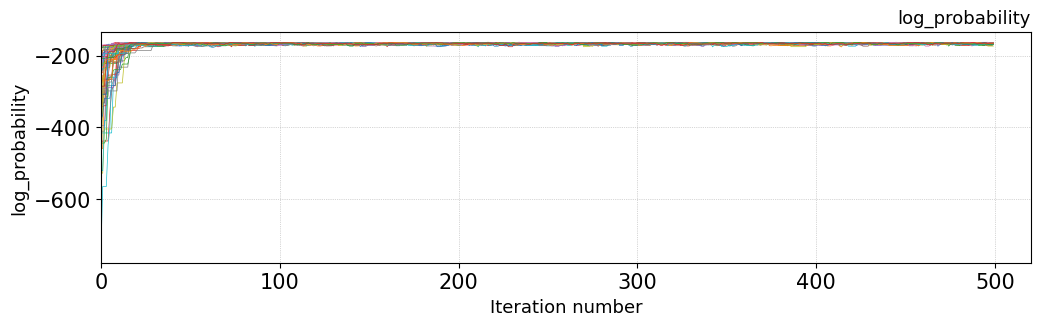

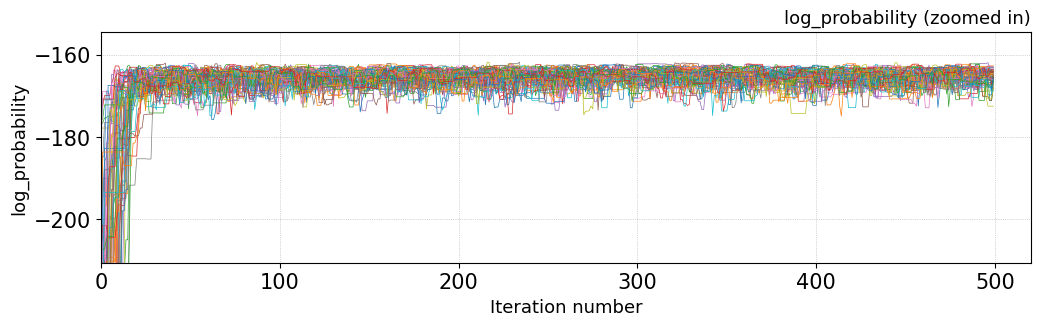

In [16]:
# Necessary imports for HDF files
from emcee.backends import HDFBackend
import os; os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# Prepare the parameters in specific order:
all_params = ["q", "iangle", "r1", "r2", "r3", "cphi3", "cphi4", "spin1", "spin2", "t1", "t2", "t3",
              "ldc1_1", "ldc1_2", "ldc1_3", "ldc1_4", "ldc2_1", "ldc2_2", "ldc2_3", "ldc2_4", "ldc3_1", "ldc3_2", "ldc3_3", "ldc3_4",
              "velocity_scale", "beam_factor1", "beam_factor2",
              "t0", "period", "pdot", "deltat", "gravity_dark1", "gravity_dark2", "absorb",
              "slope", "quad", "cube",
              "rdisc1", "rdisc2", "height_disc", "beta_disc", "temp_disc", "texp_disc", "lin_limb_disc", "quad_limb_disc", "temp_edge", "absorb_edge",
              "radius_spot", "length_spot", "height_spot", "expon_spot", "epow_spot", "angle_spot", "yaw_spot", "temp_spot", "tilt_spot", "cfrac_spot",
              "stsp11_long", "stsp11_lat", "stsp11_fwhm", "stsp11_tcen",
              "stsp12_long", "stsp12_lat", "stsp12_fwhm", "stsp12_tcen",
              "stsp13_long", "stsp13_lat", "stsp13_fwhm", "stsp13_tcen",
              "stsp21_long", "stsp21_lat", "stsp21_fwhm", "stsp21_tcen",
              "stsp22_long", "stsp22_lat", "stsp22_fwhm", "stsp22_tcen",
              "stsp1i_long", "stsp1i_lat", "stsp1i_fwhm_long", "stsp1i_fwhm_lat", "stsp1i_escale_len", "stsp1i_tcen",
             ]
param_map = {k:i for i,k in enumerate(all_params)}

# Define helper functions
def plot_logprob(ax, log_probs, color, label=None):
    '''
    '''
    steps = np.arange(0, len(log_probs))
    ax.plot(steps, np.average(log_probs, axis=1), linewidth=0.5, alpha=1.0, color=color, label=label)


def get_parameter_order(parameter_name, filters):
    for filter in filters:
        if parameter_name.endswith(f"_{filter}"):
            parameter_name = parameter_name[:-(len(filter)+1)]
            break
    return param_map[parameter_name]

def sort_parameter_names(init_params):
    init_params = init_params[
        np.argsort(
            [get_parameter_order(name, filters) for name in init_params["parameter_name"]]
        )
    ]
    return init_params


# Load the output file
output_filename = "chain_part1.h5"
mcmc_output_part1 = HDFBackend(output_filename, read_only=True)
chains = mcmc_output_part1.get_chain()
log_probs = mcmc_output_part1.get_log_prob()

# Print the shape of the chains:
print(f"Chain dimensions: {chains.shape}")
print(f"  niters   = {chains.shape[0]}")
print(f"  nwalkers = {chains.shape[1]}")
print(f"  nparams  = {chains.shape[2]}")

# Prepare the plot
iterations = np.arange(chains.shape[0])
nwalkers = chains.shape[1]

fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(111)

ax.set_xlabel("Iteration number", fontsize=13)
ax.set_ylabel("log_probability", fontsize=13)
ax.set_title("log_probability", fontsize=13, loc="right")

max_x = max(0, len(log_probs))
ax.set_xlim(0, max_x+20)

ax.tick_params(labelsize=15)
ax.grid(linewidth=0.5, linestyle=":")

for walker_id, log_prob in enumerate(log_probs.T):
    ax.plot(iterations, log_prob, linewidth=0.5)
plt.show()


# Zoom in
fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(111)

ax.set_xlabel("Iteration number", fontsize=13)
ax.set_ylabel("log_probability", fontsize=13)
ax.set_title("log_probability (zoomed in)", fontsize=13, loc="right")

max_x = max(0, len(log_probs))
ax.set_xlim(0, max_x+20)
lower = np.percentile(log_probs, 1)
upper = np.percentile(log_probs, 99)*0.95

ax.set_ylim(lower, upper)
ax.tick_params(labelsize=15)
# ax.legend(fontsize=12, loc="lower right")
ax.grid(linewidth=0.5, linestyle=":")

for walker_id, log_prob in enumerate(log_probs.T):
    ax.plot(iterations, log_prob, linewidth=0.5)
plt.show()

#

#### The y-value for each line in these plots represents the output from the <span style="font-family:Courier">log_probability()</span> function for a single walker at each iteration.

This is a measure of how good the fit is. At first glance, this fit appears to have converged rapidly since the fit does not improve after around iteration 30. The walkers then spent the remaining iterations exploring the parameter space around the minimum and building our final distributions.

However, to be more confident that this fit has converged, we should use one of the recommended statistical methods. The "autocorrelation time" (in units of number of iterations) is one of the recommended metrics that can be used to estimate convergence of an MCMC chain. It is recommended to continue your MCMC run until you reach at least 50 autocorrelation times. Python's <span style="font-family:Courier">emcee</span> provides a method to estimate autocorrelation time, which we run on our output below:


In [17]:
# Estimate autocorrelation time of our 500-iteration MCMC run with 8 free parameters:
auto_corr_time = mcmc_output_part1.get_autocorr_time(tol=0)
print(f"Autocorrelation times (per parameter) = {auto_corr_time}")
print(f"Maximum autocorrelation time: {round(max(auto_corr_time))} iterations")

Autocorrelation times (per parameter) = [40.24973933 40.16256296 40.10274826 39.18137514 36.23870746 45.0859261
 36.78815841 31.70998749]
Maximum autocorrelation time: 45 iterations


#### Since our maximum autocorrelation time is 45 iterations, we should aim for the recommended $45\times50=2250$ total iterations before we feel confident in the output.

To continue the MCMC run from where it left off and run for an additional 1750 iterations, we will update the <span style="font-family:Courier">fresh_mcmc</span> and <span style="font-family:Courier">nsteps</span> lines in the <span style="font-family:Courier">mcmc_wrapper.py</span>, while keeping the <span style="font-family:Courier">output_filename</span> parameter the same as the previous run:

><span style="font-family:Courier">
>nsteps = 1750<br/>
>output_filename = "chain.h5"<br/>
>fresh_mcmc = False<br/>

After making these changes, we re-submit our SLURM sbatch job and wait for the job to complete.

After completing another 1750 iterations on this chain, we can check our outputs again.

Chain dimensions: (2250, 64, 8)
  niters   = 2250
  nwalkers = 64
  nparams  = 8


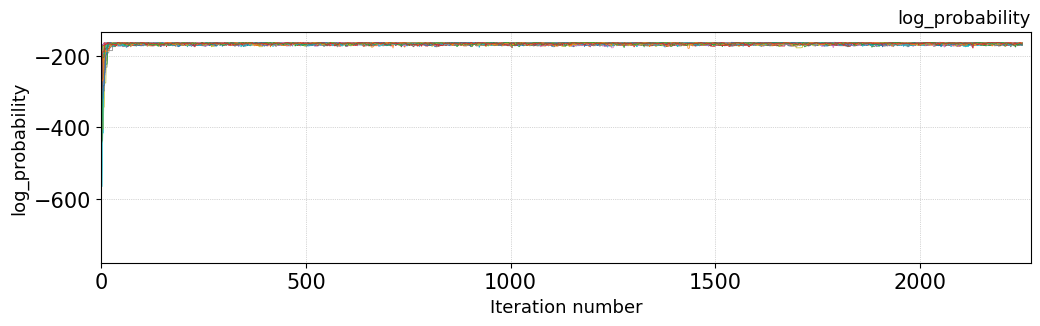

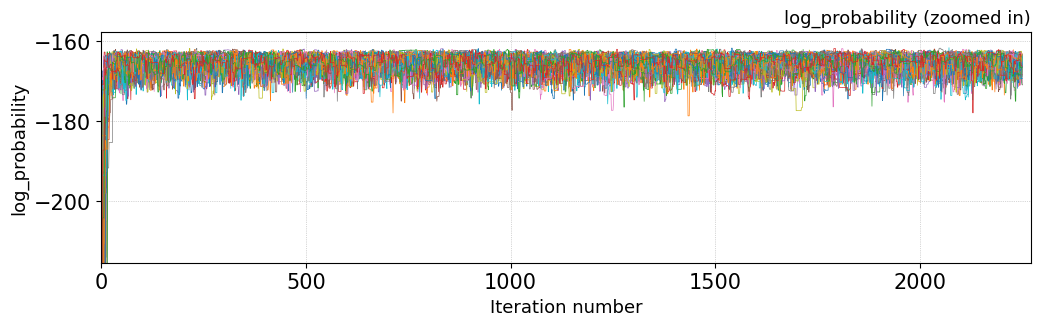

Autocorrelation times (per parameter) = [128.0033633  129.36790189 133.26475446 131.84260852  86.77922521
 150.47911044 122.37059701  91.78543433]
Maximum autocorrelation time: 150 iterations


In [18]:
# Load the updated output file
output_filename = "chain.h5"
mcmc_output = HDFBackend(output_filename, read_only=True)
chains = mcmc_output.get_chain()
log_probs = mcmc_output.get_log_prob()

# Print the shape of the chains:
print(f"Chain dimensions: {chains.shape}")
print(f"  niters   = {chains.shape[0]}")
print(f"  nwalkers = {chains.shape[1]}")
print(f"  nparams  = {chains.shape[2]}")

# Prepare the plot
iterations = np.arange(chains.shape[0])
nwalkers = chains.shape[1]

fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(111)

ax.set_xlabel("Iteration number", fontsize=13)
ax.set_ylabel("log_probability", fontsize=13)
ax.set_title("log_probability", fontsize=13, loc="right")

max_x = max(0, len(log_probs))
ax.set_xlim(0, max_x+20)

ax.tick_params(labelsize=15)
ax.grid(linewidth=0.5, linestyle=":")

for walker_id, log_prob in enumerate(log_probs.T):
    ax.plot(iterations, log_prob, linewidth=0.5)
plt.show()


# Zoom in
fig = plt.figure(figsize=(12,3))
ax = fig.add_subplot(111)

ax.set_xlabel("Iteration number", fontsize=13)
ax.set_ylabel("log_probability", fontsize=13)
ax.set_title("log_probability (zoomed in)", fontsize=13, loc="right")

max_x = max(0, len(log_probs))
ax.set_xlim(0, max_x+20)
lower = np.percentile(log_probs, 0.2)
upper = np.percentile(log_probs, 99)*0.97

ax.set_ylim(lower, upper)
ax.tick_params(labelsize=15)
# ax.legend(fontsize=12, loc="lower right")
ax.grid(linewidth=0.5, linestyle=":")

for walker_id, log_prob in enumerate(log_probs.T):
    ax.plot(iterations, log_prob, linewidth=0.5)
plt.show()

# Double check the autocorrelation time with the longer chain.
auto_corr_time = mcmc_output.get_autocorr_time(tol=0)
print(f"Autocorrelation times (per parameter) = {auto_corr_time}")
print(f"Maximum autocorrelation time: {round(max(auto_corr_time))} iterations")

#

---
#### Our updated plot shows no change in the chi-squared after the additional 1750 iterations.

Additionally, the updated autocorrelation time for this chain is 150 iterations, which is more robust now that we have a longer chain. Ideally we would run this chain for the recommended $150\times50=7500$ iterations and once again check to see if the autocorrelation time, chi-squared, and parameter values have stablized, but we'll leave our chain at 2250 iterations for this tutorial. If we wanted to be confident in our results for a publication, then we should probably continue until we reach the recommended number of iterations.

In the next cell, we plot the progress plots for each parameter to confirm that all parameters have individually converged by-eye (but again, we should use a proper statistical method to confirm convergence).

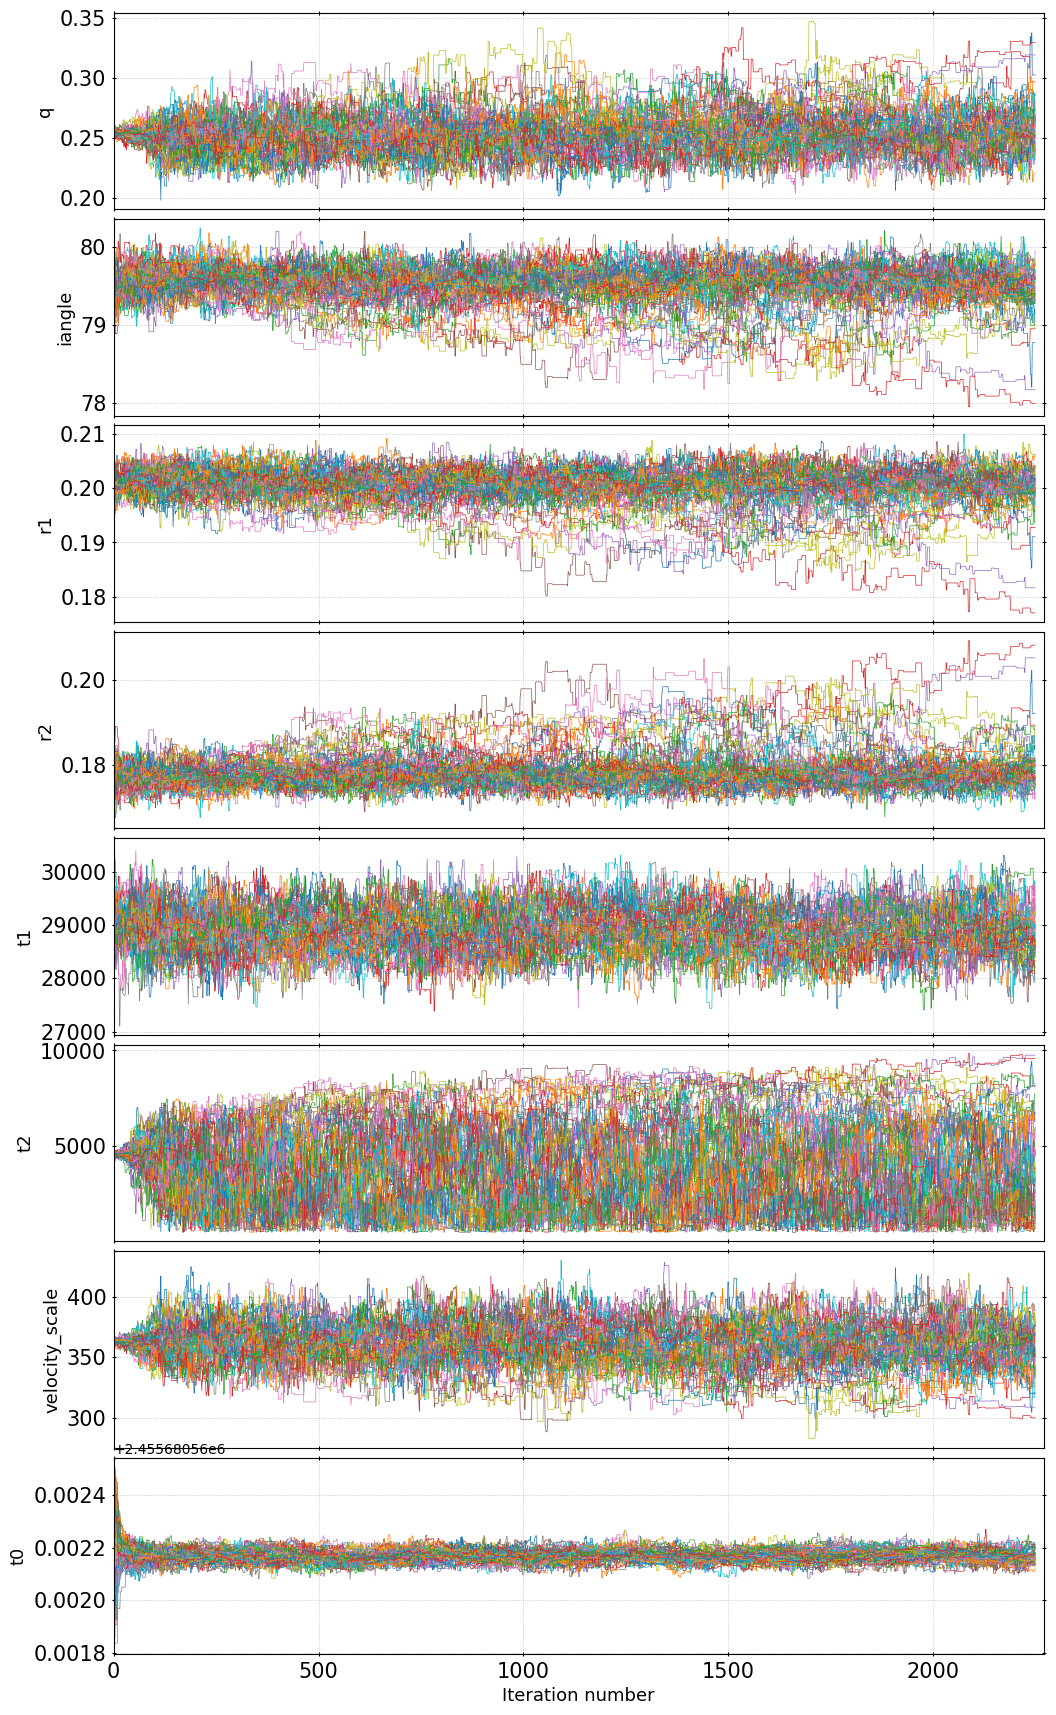

In [19]:
filters = ["V"]

init_params = np.loadtxt("init_parameters.txt", dtype=[("parameter_name", "U20"),
                                                     ("lower_limit", np.float64),
                                                     ("upper_limit", np.float64)]
                                                    )
parameter_names = init_params[
    np.argsort(
        [get_parameter_order(name, filters) for name in init_params["parameter_name"]]
    )
]["parameter_name"]


best_parameters = {k:0 for k in parameter_names}
npar = len(best_parameters)

fig = plt.figure(figsize=(12,3*npar))
plt.subplots_adjust(hspace=0.05)
for parameter_id, parameter_chains in enumerate(chains.T):
    
    ax = fig.add_subplot(npar+1, 1, parameter_id+1)
    if parameter_id+1 != npar:
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xlabel("Iteration number", fontsize=13)
    
    ax.set_ylabel(f"{parameter_names[parameter_id]}", fontsize=13)
    med = np.median(parameter_chains.T.flatten()[-500*nwalkers:])
    best_parameters[parameter_names[parameter_id]] = med

    ax.set_xlim(0, max_x+20)
    ax.tick_params(labelsize=15, bottom=True, top=True, right=True, direction="inout", which="both", left=True)
    ax.grid(linewidth=0.5, linestyle=":")

    for walker_id, parameter_values in enumerate(parameter_chains):
        ax.plot(iterations, parameter_values, linewidth=0.5)
    # ax.axhline(med, zorder=9, color="cyan")
plt.show()


---

## Creating the final corner plot.

Before we create a plot of our final parameter values, we must first remove the part of the MCMC chain before the walkers converged. This will leave us with only the results where the walkers were sampling their final distributions. The part of the MCMC chain before convergence is called the "burn-in".

The fit can be considered converged when the chi-squared and all parameters have stablized, but it's sometimes recommended to use about 5 times the autocorrelation time as the burn-in value. In our case, this is $5\times150=750$, so we throw out the first 750 iterations and use the remaining 1500 iterations for our final distributions. Since each walker provides +1 sample at each iteration for our final distribution plots, our 64 walkers and 1500 iterations results in $64\times1500=96000$ samples.

96000 total samples is more than enough for extracting reliable statistics, but we may benefit from reducing this to make the data more manageable for storing, plotting, and later analysis. In that case, we can sample randomly from the flattened parameter lists (combine all like-parameters across walkers, then pull N random samples for each parameter).

Let's plot our final corner plot now:
<ol>
    <li>Remove the burn-in
    <ul><li>Roughly 5 times the autocorrelation time</li></ul>
    </li>
    <li>Flatten the output by combining walkers</li>
    <li>Thin the remaining samples
    <ul><li>Sample N times from each parameter array</li></ul>
    </li>
    <li>Create a corner plot from the thinned samples</li>
</ol>

In [20]:
# Estimate burn-in
burn_in = 5*round(max(auto_corr_time))
print(f"Burn-in: {burn_in} iterations")

# Remove burn-in and flatten the chain
print(f"Chain dimensions: {chains.shape} (original)")
print(f"    niters   = {chains.shape[0]}")
print(f"    nwalkers = {chains.shape[1]}")
print(f"    nparams  = {chains.shape[2]}")
chained_processed = mcmc_output.get_chain(discard=burn_in, flat=True)
print(f"Chain dimensions: {chained_processed.shape} (processed)")

# Randomly sample the flattened chain for 40000 samples
sample_indices = np.random.choice(len(chained_processed), size=40000, replace=False)
chains_sampled = chained_processed[sample_indices]
print(f"Chain dimensions: {chains_sampled.shape} (down-sampled)")

Burn-in: 750 iterations
Chain dimensions: (2250, 64, 8) (original)
    niters   = 2250
    nwalkers = 64
    nparams  = 8
Chain dimensions: (96000, 8) (processed)
Chain dimensions: (40000, 8) (down-sampled)


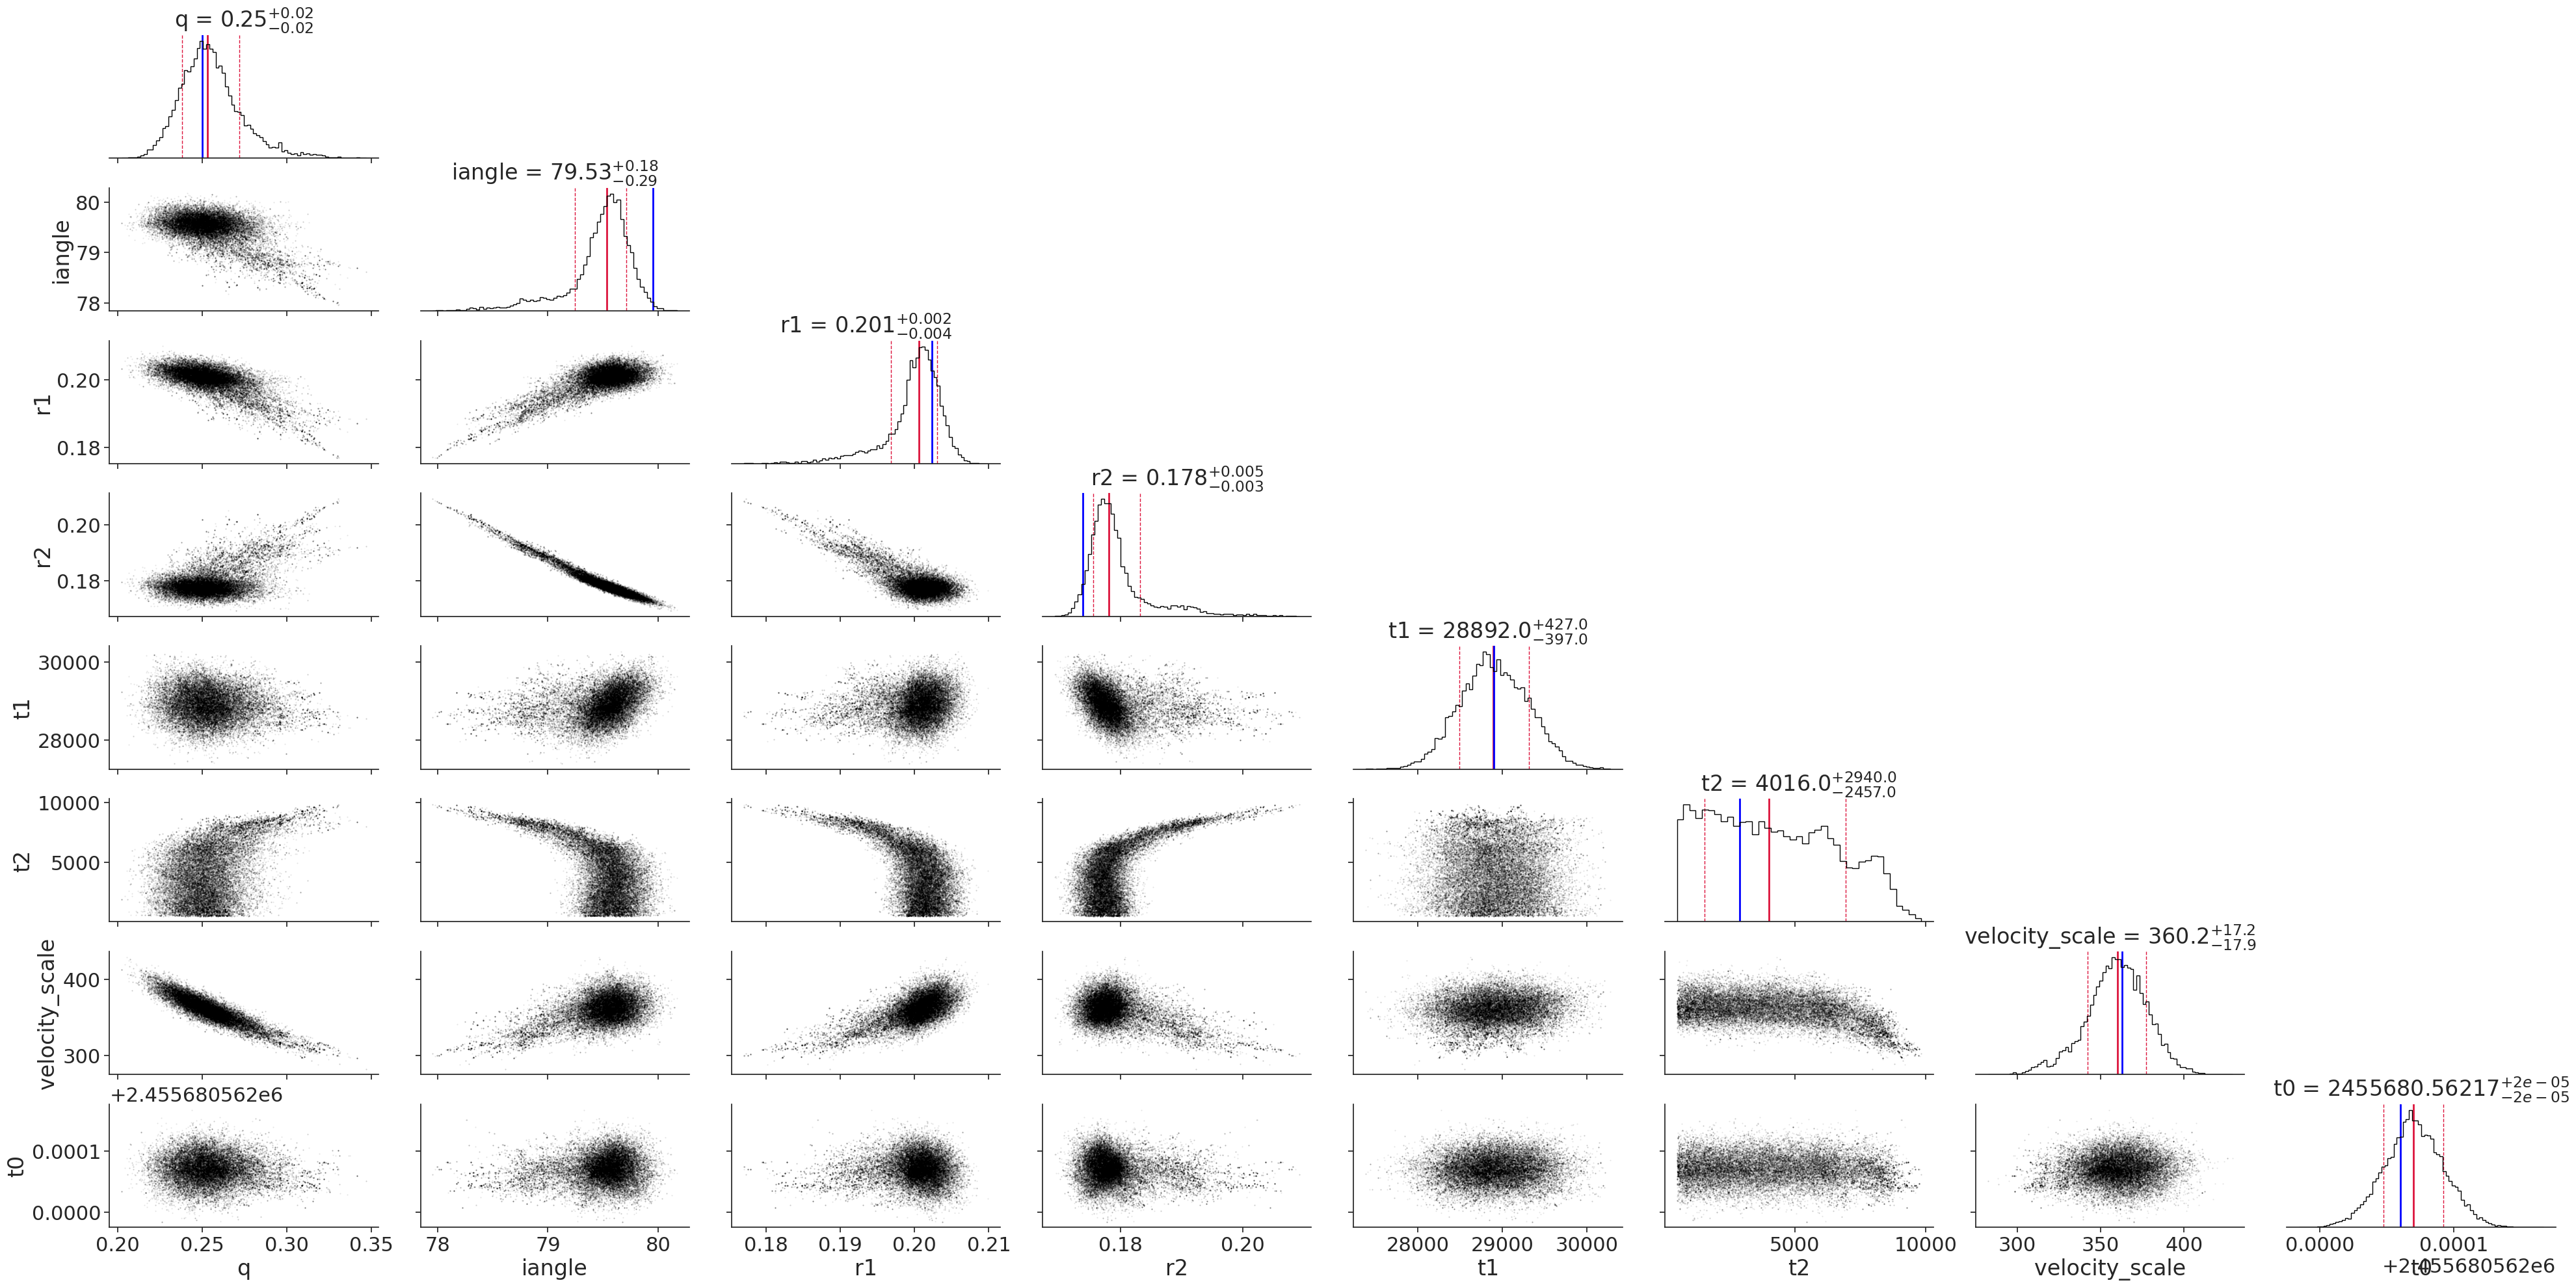

In [21]:
# Create a corner plot with seaborn

# Save the chains array to a dataframe with column names:
chains_df = pd.DataFrame(chains_sampled, columns=parameter_names)
sns.set(style="ticks", color_codes=True, font_scale=2)
g = sns.PairGrid(chains_df, corner=True, diag_sharey=False, despine=True, aspect=2)
g.map_diag(plt.hist, bins="scott", histtype="step", color="black", density=True)
g.map_offdiag(plt.scatter, alpha=0.1, marker=".", color="black", s=1)

# Define the number of decimals to display when printing values on plots.
decimals_by_parameter = {"q":2, "iangle":2, "r1":3, "r2":3, "velocity_scale":1, "t1":0, "t2":0, "t0":5,}
dbp = decimals_by_parameter # Short-hand version

# Parameter values from Barlow+2013 will be marked in blue
parameters_true = {"q":0.25, "r1":0.20238, "r2":0.17381, "velocity_scale":363, "t1":28900, "t2":2900, "t0":2455680.562160, "iangle":79.95}
for i, key in enumerate(chains_df.keys()):
    median    = np.percentile(chains_df[key], 50)
    onesigup  = np.percentile(chains_df[key], 84.13) - median
    onesigdown = median - np.percentile(chains_df[key], 15.87)
    
    g.axes[i,i].set_title(f"{key} = ${np.round(median,dbp[key])}^{{+{np.round(onesigup, dbp[key])}}}_{{-{np.round(onesigdown,dbp[key])}}}$")

    g.axes[i,i].axvline(x=median,            color="crimson", linewidth=2)
    g.axes[i,i].axvline(x=median+onesigup,   color="crimson", linewidth=1, linestyle="--",)
    g.axes[i,i].axvline(x=median-onesigdown, color="crimson", linewidth=1, linestyle="--",)

    g.axes[i,i].axvline(x=parameters_true[key], color="blue", linewidth=2)

## Interpreting your corner plot.

Looking at our corner plot, we see that most parameters agree well with the values from Barlow+2013 (blue lines) and that there are clear correlations in the expected parameters (radius and inclination).

The inclination, radii, and primary temperature values are also well-constrained with single-peaked distributions (with long tails). However, I usually do not trust such small inclination uncertainties.

The velocity scale is constrained through our prior on the velocity semi-amplitude and the orbital inclination (through the eclipse shapes). We will need to convert velocity scale back into velocity semi-amplitude to compare to observation, though.

I would consider temperature of the secondary (t2) as entirely unconstrained. The resulting parameter distribution is pretty much uniformly distributed over a huge range, suggesting that any value within that range can reproduce the data equally well. Ideally, we would simultaneously fit data from two filters. For typical eclipsing binaries, the eclipse depths will differ between the filters and this difference is based on the ratio of effective temperatures of the stars. However, for an HW Vir, the secondary eclipse is the eclipse of the primary's reflected light, so the secondary's temperature may be difficult to extract this way.

The time of primary conjunction appears to be constrained to within a $1\sigma$ uncertainty of about 1.7 seconds. If we trusted this value, then we have a new measurement for a future orbital decay analysis.

---

## Creating a corner plot using calculated parameters based on our fitted parameters.

We are not limited to plotting what was fitted. Similar to how we built our priors, we may calculate other values using our fitted parameters to build distributions on properties such as mass and physical radius.

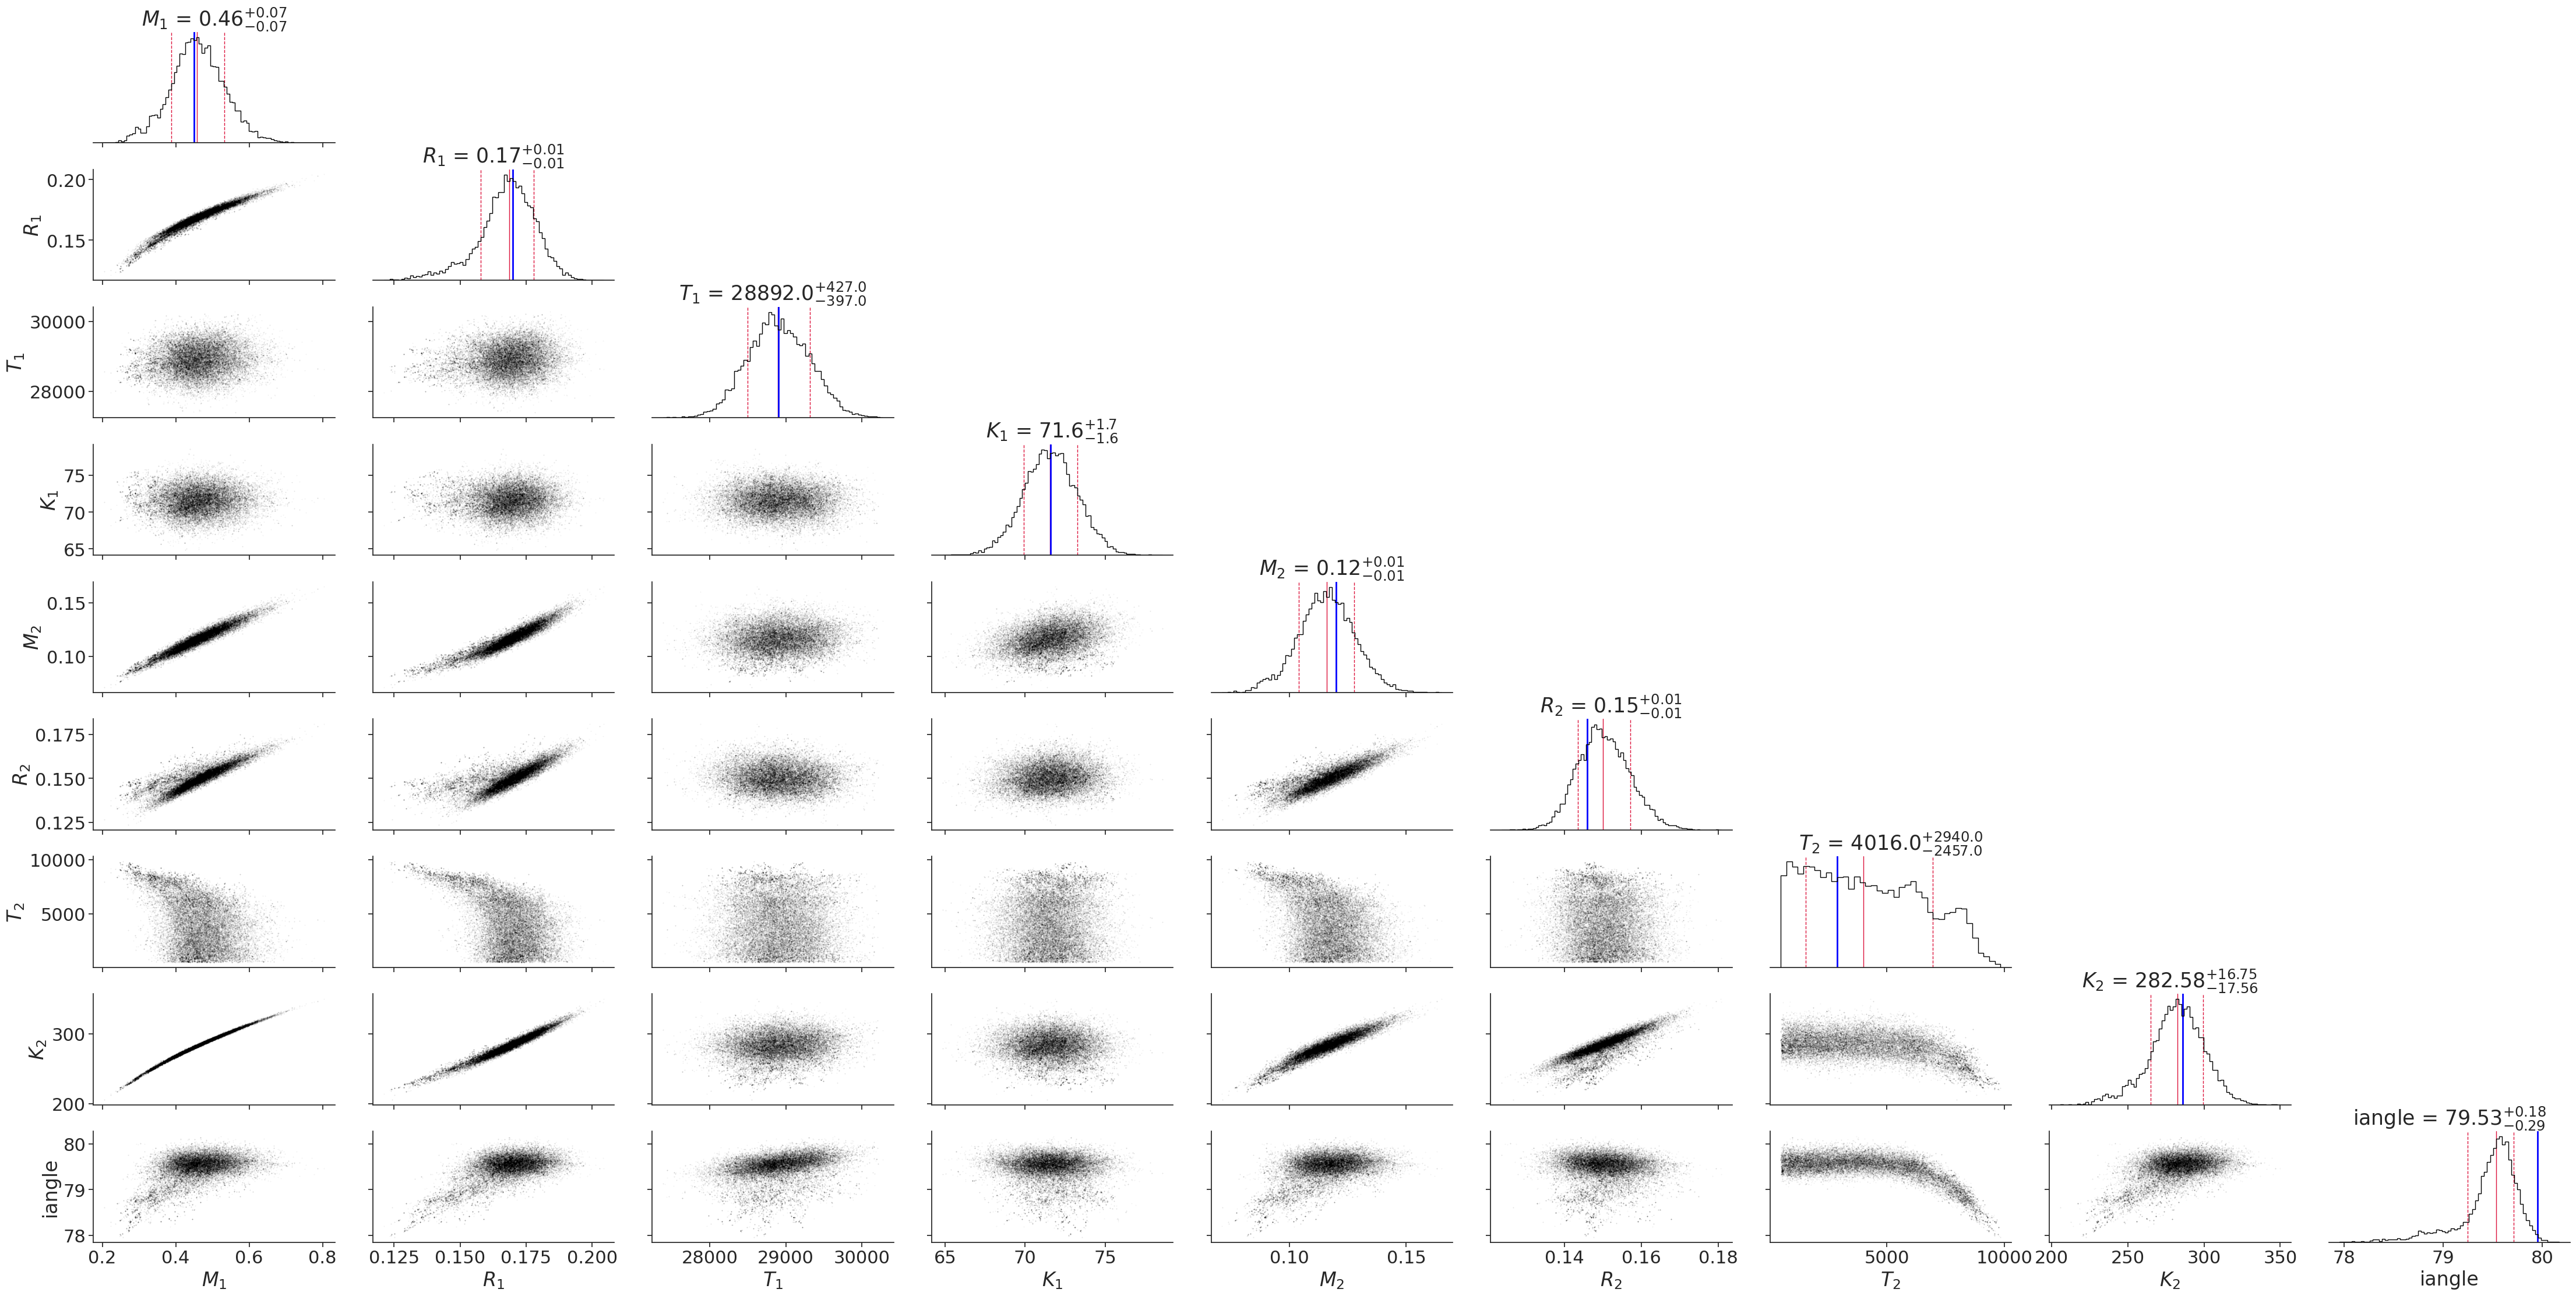

In [22]:
# Define the constants needed to calculate stellar properties from fitted parameters.
G = 6.67e-11 # mks
M_sun = 1.9891e+30 # kg
tperiod = 0.1185079936 # days

# Calculate M2, M1, K2, K1, a, R1, R2
chains_df_copy = chains_df.copy()
chains_df_copy['M2'] = chains_df_copy['q']/(1+chains_df_copy['q'])*tperiod*(24*3600)/(2*np.pi*G)*(chains_df_copy['velocity_scale']*1000)**3/M_sun
chains_df_copy['M1'] = 1/(1+chains_df_copy['q'])*tperiod*(24*3600)/(2*np.pi*G)*(chains_df_copy['velocity_scale']*1000)**3/M_sun
chains_df_copy['K1'] = chains_df_copy["q"]/(1+chains_df_copy['q'])*chains_df_copy['velocity_scale']*np.sin(np.pi*chains_df_copy['iangle']/180.)
chains_df_copy['K2'] = 1/(1+chains_df_copy['q'])*chains_df_copy['velocity_scale']*np.sin(np.pi*chains_df_copy['iangle']/180.)
chains_df_copy["a"]  = ((tperiod*86400)**2 * G * (2e30*(chains_df_copy["M1"]+chains_df_copy["M2"]))/4/np.pi/np.pi)**(1./3)/7e8
chains_df_copy["R1"] = chains_df_copy["r1"]*chains_df_copy["a"]
chains_df_copy["R2"] = chains_df_copy["r2"]*chains_df_copy["a"]

# Restrict which columns will be plotted
chains_df_copy = chains_df_copy[["M1", "R1", "t1", "K1", "M2", "R2", "t2", "K2", "iangle"]]

# Rename columns so they look nice on the plot.
chains_df_copy.rename({"M1":"$M_1$", "M2":"$M_2$", "R1":"$R_1$","R2":"$R_2$", "K1":"$K_1$","K2":"$K_2$", "t1":"$T_1$", "t2":"$T_2$", "t0":"$T_0$"}, axis=1, inplace=True)

# Remake the corner plot.
g2 = sns.PairGrid(chains_df_copy, corner=True, diag_sharey=False, despine=True, aspect=2)
g2.map_diag(plt.hist, bins='scott', histtype='step', color='black', density=True)
g2.map_offdiag(plt.scatter, alpha=0.05, marker='.', color='black', s=1)


# Define the number of decimals to display when printing values on plots.
decimals_by_parameter2 = {"q":2, "iangle":2, "$R_1$":2, "$R_2$":2, "$K_1$":1, "$K_2$":2, "$M_1$":2, "$M_2$":2, "$T_1$":0, "$T_2$":0, "$T_0$":5, "a":2}
dbp = decimals_by_parameter2

parameters_true2 = {"q":0.25, "r1":0.20238, "r2":0.17381, "t1":28900, "t2":2900, "t0":2455680.562160, "iangle":79.95,
                    "$M_1$":0.45, "$M_2$":0.12, "$T_1$":28900, "$T_2$":2900, "$K_1$":71.6, "$K_2$":286, "$R_1$":0.17, "$R_2$":0.146,
                    "$T_0$":2455680.562160, "a":0.84,}

for i, key in enumerate(chains_df_copy.keys()):
    median    = np.percentile(chains_df_copy[key], 50)
    onesigup  = np.percentile(chains_df_copy[key], 84.13) - median
    onesigdown = median - np.percentile(chains_df_copy[key], 15.87)
    
    g2.axes[i,i].set_title(f"{key} = ${np.round(median,dbp[key])}^{{+{np.round(onesigup, dbp[key])}}}_{{-{np.round(onesigdown,dbp[key])}}}$", fontsize=25)

    g2.axes[i,i].axvline(x=median,            color="crimson", linewidth=1)
    g2.axes[i,i].axvline(x=median+onesigup,   color="crimson", linewidth=1, linestyle="--",)
    g2.axes[i,i].axvline(x=median-onesigdown, color="crimson", linewidth=1, linestyle="--",)

    g2.axes[i,i].axvline(x=parameters_true2[key], color="blue", linewidth=2)


## Special notes about modeling accreting systems:
Modeling accreting binaries is slightly more complicated than detached binaries. If the binary is actively accreting, then the radius of the donor star is defined by the Roche geometry, which is defined by the mass ratio and orbital separation. lcurve treats the orbital separation as $a=1.0$, so, in this case, the mass ratio controls the donor radius for fitting purposes. Alternatively, if you have a donor radius approximation from another observation, then you can use that to place constraints on the mass ratio.


If you have an accreting system, then the donor star must be star2 and the scaled radius of star2 must be fixed at <span style="font-family:Courier">r2 = -1</span>. This tells lroche to force the donor star to completely fill its Roche lobe. This option is not available for star1, so be sure to assign the donor star to star2 and adjust your mass ratio to satisfy $q=\frac{M_2}{M_1}$ if necessary.

To enable an accretion disc in lcurve, you will need to adjust the parameters file to include <span style="font-family:Courier">add_disc = 1</span> and <span style="font-family:Courier">opaque = 1</span>

The accretion disc is modeled by a simplified axisymmetric flared disc. The following parameters in the parameters file are used to model the disc:
><span style="font-family:Courier">
>rdisc1         = -1 0.01 0.0001 0 1<br/>
>rdisc2         = 0.375 0.01 0.002 0 1<br/>
>height_disc    = 0.05 0.002 0.0003 0 1<br/>
>beta_disc      = 1.5 0.01 1e-05 0 1<br/>
>temp_disc      = 13850 700 100 0 1<br/>
>texp_disc      = -1.8 0.2 0.01 0 1<br/>
>lin_limb_disc  = 0.3 0.02 0.001 0 1<br/>
>quad_limb_disc = 0 0.02 0.0001 0 1<br/>
>temp_edge      = 4500 200 100 1 1<br/>
>absorb_edge    = 1.0 0.1 0.02 0 1<br/>
></span>

<ul>
    <li><span style="font-family:Courier">rdisc1</span>
        <ul>
            <li>Scaled distance from the center of the accretor to the inner edge of the disc</li>
            <li>Set this to $-1$ to fix it to the location of the accretor's surface. This would cover the physical "boundary layer" of the binary, so it is maybe not physical if you see X-rays in your system</li>
        </ul>
    </li>
    <li><span style="font-family:Courier">rdisc2</span>
        <ul>
            <li>Scaled distance from the center of the accretor to the outer edge of the disc</li>
            <li>Set this to $-1$ to fix it at the location where the accretion stream impacts the outer disc (controlled by the <span style="font-family:Courier">radius_spot</span> parameter)</li>
        </ul>
    </li>
    <li><span style="font-family:Courier">height_disc</span>
        <ul>
            <li>Scaled half-height of the disc, measured at the center of the donor a distance $a$ away</li>
            <li>This is the half-thickness of the full disc. Since the disc is symmetric, this parameter is the height of the disc above the orbital plane</li>
        </ul>
    </li>
    <li><span style="font-family:Courier">beta_disc</span>
        <ul>
            <li>Exponent describing the flared shape of the disc</li>
            <li>I usually keep this fixed between the default 1.5-2.0, but the exact value has not mattered for my work</li>
        </ul>
    </li>
    <li><span style="font-family:Courier">temp_disc</span>
        <ul>
            <li>Temperature of outer part of the disc </li>
            <li>Used for flux normalization of the disc</li>
            <li>This is only a temperature in the sense of a blackbody contribution, not necessarily true physical temperature from thermal emission</li>
        </ul>
    </li>
    <li><span style="font-family:Courier">texp_disc</span>
        <ul>
            <li>Controls the radial surface brightness profile over disc</li>
        </ul>
    </li>
    <li><span style="font-family:Courier">lin_limb_disc</span> and <span style="font-family:Courier">quad_limb_disc</span>
        <ul>
            <li>Limb darkening of the outer edge of the disc. I keep these fixed at the default 0.3 and 0.0 since I have no reason to change them</li>
        </ul>
    </li>
    <li><span style="font-family:Courier">temp_edge</span>
        <ul>
            <li>Temperature of the outer part of the accretion disc, facing radially outward (think of the outer wall of a cylinder)</li>
            <li>Limb darkening is applied here</li>
        </ul>
    </li>
    <li><span style="font-family:Courier">absorb_edge</span>
        <ul>
            <li>Fraction of irradiating bolometric flux from the donor star that is absorbed and re-emitted by the outer edge of the disc</li>
            <li>Necessary for sdOB+WD binaries</li>
        </ul>
    </li>
</ul>


### Visualizing an eclipsing sdOB + WD binary to confirm system geometry.
Just like before, we can make use of the model.lcurve.visualize_data() method to visualize the system geometry of a system with an accretion disc. In this example, there is no bright spot, so the accretion stream does not show up in the visualization.

End of file reached.
113 lines read from parameters_files/parameters_disc.txt


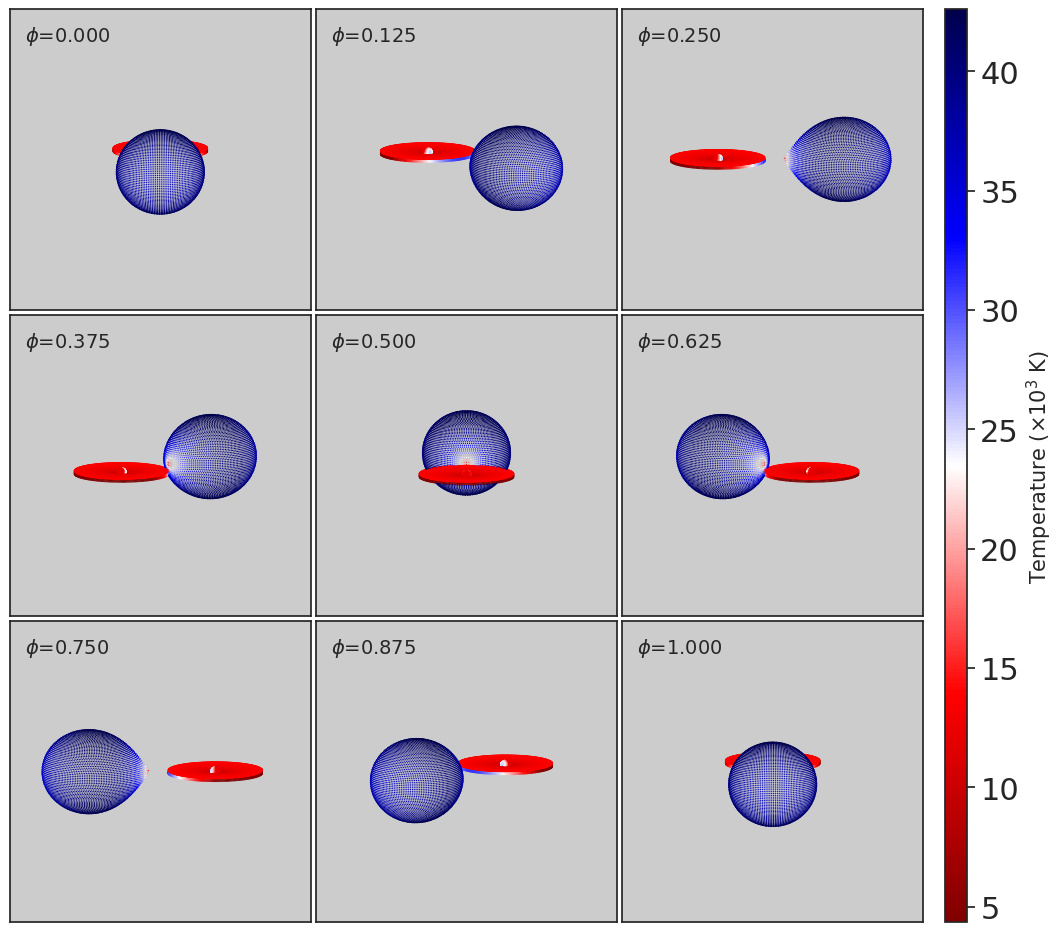

In [23]:
# Create a new model object using the parameters file for an accreting binary.
model_disc = Lcurve_model(parameters_file="parameters_files/parameters_disc.txt")

grid_resolution = 80
model_disc.parameters.finite_irr12 = True
model_disc.parameters.finite_irr21 = False
model_disc.parameters.nlat1f = grid_resolution
model_disc.parameters.nlat1c = grid_resolution
model_disc.parameters.nlat2f = grid_resolution
model_disc.parameters.nlat2c = grid_resolution
model_disc.parameters.nrad = 50

# Plot the sky projection.
plot_2d_projection(model_disc, figsize=(11, 11))